# Notebook 01: Matrix Multiplication — From Python Loops to the GPU

---

## What This Notebook Covers

This notebook teaches **matrix multiplication** from the ground up — first as a triple-nested Python loop, then progressively replaced with faster and faster machinery until we hit the bare metal of a CUDA kernel running on the GPU. Matrix multiplication is the operation that *every* neural network is built on, so we earn intuition for the whole rest of the course right here. We will learn:

1. **MNIST data loading and tensor basics** — pickle, gzip, NumPy/PyTorch tensors, indexing, reshaping
2. **A toy `Matrix` class and the pivot to PyTorch tensors** — why we don't stay in pure Python
3. **Pseudo-random number generators** — what `torch.randn` is actually doing under the hood
4. **Matmul from scratch with three nested loops** — the slow ground truth
5. **Numba-accelerated dot product** — replacing the innermost loop with compiled C
6. **Broadcasting** — eliminating an entire Python loop with a shape-based vectorization rule
7. **Einstein summation (`einsum`)** — a compact notation for a whole family of tensor operations
8. **PyTorch's `@` operator** — production-grade matmul via BLAS
9. **CUDA kernels** — what it means to run code on a GPU
10. **PyTorch on the GPU** — the one-line trick that buys you a ~100,000,000× speedup over a naive Python loop

The same physical operation (a 5 × 784 by 784 × 10 multiply) reappears in eight different costumes — each costume is one lesson about how performance is bought in numerical computing.

---

## Why Matrix Multiplication?

Every layer of every neural network is, fundamentally, a matrix multiplication followed by a nonlinearity. The forward pass of a transformer is mostly matmuls. The attention computation in Stable Diffusion's U-Net is matmuls. Convolution itself can be unrolled into a matmul. When the field says "GPUs are essential for deep learning," what it means is that GPUs are specifically engineered to do many matmuls in parallel.

So:

- If you understand matmul at the level of "what's happening per element," you can read any neural network architecture diagram and predict its compute cost.
- If you understand *why* the naive triple-loop is slow and *how* broadcasting, BLAS, and CUDA each fix a different bottleneck, you understand how the entire numerical-computing stack works.
- If you can implement matmul four different ways (loops, dot product, broadcasting, einsum), you'll never again be confused by an obscure shape error.

There's a second reason to dwell here: this notebook also doubles as an **introduction to tensors and PyTorch**, which we'll use for the rest of the course. The matmul story is just the spine.

---

## Prerequisites

You only need basic Python — comprehensions, functions, classes, `import`. We'll define everything else (tensors, broadcasting, decorators, CUDA, einsum) from first principles as it comes up.

Helpful but not required:

- Comfort with the idea of a 2-D NumPy array (we'll re-introduce it as a PyTorch tensor).
- Vague memory of what a dot product is from linear algebra (we'll re-derive it).
- A GPU on this machine if you want to actually run §11–§12 — but you can read them and understand them without one.

---

## Relationship to `01_matmul_with_comments.ipynb`

This notebook expands on the `_with_comments` version with three additions:

1. **`What does the code above do?` cells** after every meaningful code block, with prose explanations and tables.
2. **Three deep-dive sections** on broadcasting, einsum, and the CUDA execution model — the conceptual pieces that the inline comments can only sketch.
3. **A summary table** comparing all six matmul implementations.

The code itself is preserved unchanged from `_with_comments` so the two files give consistent results when run.

---

## Google Colab Setup

Run the cells below **once** at the start of each Colab session. They mount Google Drive, set the working directory, and install the packages this notebook needs. Notebook 01 doesn't import from `miniai` (it's foundations — we build matmul from scratch), but the clone of the course repo is kept for consistency with the rest of the `_colab` notebooks.

**GPU note:** §9.3 (real CUDA with Numba) and §10 (PyTorch on the GPU) require a GPU runtime. Go to **Runtime → Change runtime type → Hardware accelerator: GPU (T4)** before running those cells. The rest of the notebook works on CPU.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.chdir('/content/drive/MyDrive/Fast.AI_Colab')
print(os.getcwd())

/content/drive/MyDrive/Fast.AI_Colab


In [3]:
# Install required packages
# numba is the only one specific to this notebook (used in §5 and §9 for CUDA);
# the rest are the standard install list across all _colab notebooks.
!pip install -q fastcore fastai diffusers datasets torcheval accelerate numba

# Clone the fast.ai Part 2 course repo (kept for consistency; not actually
# imported in notebook 01).
if not os.path.exists('course22p2'):
    !git clone https://github.com/fastai/course22p2.git

# Add miniai to the Python path (also for consistency)
import sys
sys.path.insert(0, os.path.join(os.getcwd(), 'course22p2'))

print('Setup complete.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 4.7 MB/s eta 0:00:00
Setup complete.


---

*The cells above are Colab-specific setup. The content below is the same as the source notebook (`01_matmul_explained.ipynb`), unchanged.*

---

# Part 0: Setup and Imports

The "foundations" of this course are intentionally tiny — Python itself, matplotlib for plotting, the Python standard library, and Jupyter. Everything else (PyTorch, neural network primitives, training utilities) gets built up from these. The imports below pull in *only* the standard-library tools we need to load and display MNIST.

In [4]:
# ============================================================================
# IMPORTING REQUIRED LIBRARIES
# ============================================================================
# Each library serves a specific purpose:

from pathlib import Path      # For handling file paths in a clean, cross-platform way
import pickle                  # For loading/saving Python objects to files
import gzip                    # For reading compressed (.gz) files
import math                    # For mathematical functions like sqrt, ceil, etc.
import os                      # For operating system functions (file operations)
import time                    # For measuring execution time
import shutil                  # For high-level file operations (copy, move)
import matplotlib as mpl       # The main matplotlib library
import matplotlib.pyplot as plt  # For creating plots and displaying images

**What does the code above do?**

Imports the seven standard-library + matplotlib modules we'll lean on for the data-loading half of the notebook:

| Module | Role here |
|---|---|
| `pathlib.Path` | Cross-platform file paths — replaces messy string concatenation like `"data/" + filename` |
| `pickle` | Serialize/deserialize Python objects to disk (MNIST ships as a pickle file) |
| `gzip` | Read the `.gz`-compressed pickle without first decompressing it manually |
| `math` | `sqrt`, `ceil` — we'll use `ceil` later when computing CUDA grid dimensions |
| `os` | OS-level file operations |
| `time` | Wall-clock timing |
| `shutil` | High-level file copy/move/delete |
| `matplotlib` / `pyplot` | Plotting and image display |

Nothing here that touches a neural network yet. PyTorch enters in Part 2.

---

# Part 1: Loading and Understanding MNIST

## What is MNIST?

**MNIST** (Modified National Institute of Standards and Technology) is the canonical "Hello World" dataset of machine learning: 70,000 grayscale images of handwritten digits 0–9, each 28 × 28 pixels. It was created by Yann LeCun and collaborators in the 1990s for training postal-code recognizers, and it remains the standard sanity-check for any new model. Tiny, fast to download, easy to visualize, and just hard enough to be interesting.

Each image arrives as a *flat* vector of 784 = 28 × 28 floats in `[0, 1]` — 0 is black, 1 is white. Each label is an integer in `{0, 1, …, 9}` giving the correct digit.

## Why does this notebook bother loading MNIST?

We need *something* to multiply matrices with. A 50,000 × 784 tensor of pixel values × a 784 × 10 weight matrix is a textbook one-layer classifier and gives the matmuls in §4–§9 something concrete to chew on. The point isn't to train a model — it's to give the matmuls realistic shapes so the timings mean something.

---

## 1.1 Setting up the download

In [5]:
# ============================================================================
# SETTING UP DATA DOWNLOAD
# ============================================================================

# The URL where the MNIST dataset is hosted (compressed as a .gz file)
# This is a pickle file - a way to save Python objects to disk
MNIST_URL='https://github.com/mnielsen/neural-networks-and-deep-learning/blob/master/data/mnist.pkl.gz?raw=true'

# Create a Path object for the 'data' directory
# Path is better than strings for file paths - it works on Windows, Mac, and Linux
path_data = Path('data')

# Create the 'data' directory if it doesn't exist
# exist_ok=True means don't raise an error if it already exists
path_data.mkdir(exist_ok=True)

# Create the full path to where we'll save the downloaded file
# The '/' operator with Path objects joins paths together
path_gz = path_data/'mnist.pkl.gz'

print(f"Data will be saved to: {path_gz}")

Data will be saved to: data/mnist.pkl.gz


**What does the code above do?**

Prepares the destination for the download but doesn't fetch anything yet:

- `MNIST_URL` is the public mirror of the LeCun pickle, hosted on Michael Nielsen's "Neural Networks and Deep Learning" GitHub. The `?raw=true` query string is GitHub-specific — it tells the server to send the file bytes, not the styled HTML "view file" page.
- `Path('data')` creates a path object pointing at a `data/` folder relative to the notebook's working directory.
- `path_data.mkdir(exist_ok=True)` ensures that folder exists. `exist_ok=True` makes it a no-op if it's already there (without that flag, you'd get a `FileExistsError`).
- `path_data / 'mnist.pkl.gz'` uses `Path`'s overloaded `/` operator — much cleaner than `os.path.join`.

## 1.2 Downloading the file

In [6]:
# ============================================================================
# DOWNLOADING THE DATASET
# ============================================================================

from urllib.request import urlretrieve  # Import the download function

# Only download if the file doesn't already exist
# This saves time if you run the notebook multiple times
if not path_gz.exists():
    print("Downloading MNIST dataset...")
    urlretrieve(MNIST_URL, path_gz)
    print("Download complete!")
else:
    print("Dataset already downloaded!")

Download complete!


**What does the code above do?**

Downloads the dataset *only* if it isn't already on disk. The `if not path_gz.exists()` guard is a small thing but it's what makes the notebook safe to re-run — no waiting on a re-download every time you restart the kernel.

`urlretrieve(url, target)` is the simplest one-line download in the Python standard library. There's no progress bar; it just blocks until done. For real production code you'd use `requests` with streaming, but for a one-off 16-MB pickle this is fine.

## 1.3 Verify the download landed

In [7]:
# ============================================================================
# VERIFY THE DOWNLOAD
# ============================================================================
# Let's check that the file was downloaded correctly
# The ! at the start means "run this as a shell command" (not Python)
# 'ls -l' lists files with details (size, date, etc.)

!ls -l data

total 16653
-rw------- 1 root root 17051982 Jun  2 19:15 mnist.pkl.gz


**What does the code above do?**

The leading `!` is Jupyter syntax for "run this as a shell command, not as Python." `ls -l data` lists the contents of the `data/` folder with file sizes and timestamps. We're checking that the `mnist.pkl.gz` is there and has roughly the expected size (~16 MB).

The `!`-prefixed line is a Jupyter convenience — under the hood it spawns a subshell. It won't work in a plain `.py` script.

## 1.4 Loading the data from the compressed pickle

In [8]:
# ============================================================================
# LOADING THE DATA FROM THE COMPRESSED FILE
# ============================================================================

# Open the compressed file and load its contents
# Let's break this down step by step:

# gzip.open() - Opens a .gz compressed file
# 'rb' means "read binary" - we're reading raw bytes, not text
# pickle.load() - Converts the saved bytes back into Python objects
# encoding='latin-1' - Specifies how to interpret text in the file

with gzip.open(path_gz, 'rb') as f:
    # The file contains 3 tuples: training data, validation data, and test data
    # Each tuple has (images, labels)
    # We use _ to ignore the test data (we don't need it right now)
    ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding='latin-1')

# What we now have:
# x_train: 50,000 training images (each image is a list of 784 pixel values)
# y_train: 50,000 labels (the correct digit for each training image)
# x_valid: 10,000 validation images (for testing our model)
# y_valid: 10,000 validation labels

print(f"Training images: {len(x_train)}")
print(f"Training labels: {len(y_train)}")
print(f"Validation images: {len(x_valid)}")
print(f"Validation labels: {len(y_valid)}")

Training images: 50000
Training labels: 50000
Validation images: 10000
Validation labels: 10000


**What does the code above do?**

Reads the gzipped pickle in one shot:

1. `gzip.open(path_gz, 'rb')` opens the file in **read-binary** mode, decompressing on the fly — we never touch the uncompressed bytes ourselves.
2. `pickle.load(f, encoding='latin-1')` deserializes the file. The `latin-1` encoding is needed because the pickle was originally created on Python 2, which stored strings as raw bytes. Without this we'd see a `UnicodeDecodeError`.
3. The pickle contains a tuple `((x_train, y_train), (x_valid, y_valid), (x_test, y_test))`. We **destructure** all three at once and assign the test split to `_` to indicate "we don't use this."

After this cell:

| Variable | Shape | Type | What it holds |
|---|---|---|---|
| `x_train` | 50,000 × 784 (as a NumPy ndarray) | float32 | Flattened pixel values in `[0, 1]` |
| `y_train` | 50,000 | int64 | The correct digit 0–9 for each training image |
| `x_valid` | 10,000 × 784 | float32 | Validation pixels |
| `y_valid` | 10,000 | int64 | Validation labels |

These are still NumPy arrays at this point — we'll convert them to PyTorch tensors in §1.10.

## 1.5 What does one image actually look like as numbers?

In [9]:
# ============================================================================
# EXPLORING THE DATA: WHAT DOES AN IMAGE LOOK LIKE?
# ============================================================================

# Let's look at the first image in our training set
# First, convert it to a Python list (easier to inspect)
lst1 = list(x_train[0])

# Let's look at just 10 pixel values (positions 200-210)
# These are somewhere in the middle of the image
vals = lst1[200:210]

print("10 pixel values from the first image:")
print(vals)
print()
print("What do these numbers mean?")
print("- 0.0 = completely black (no ink)")
print("- 1.0 = completely white (full ink)")
print("- Values in between = shades of gray")

10 pixel values from the first image:
[np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.19140625), np.float32(0.9296875), np.float32(0.98828125), np.float32(0.98828125), np.float32(0.98828125), np.float32(0.98828125), np.float32(0.98828125)]

What do these numbers mean?
- 0.0 = completely black (no ink)
- 1.0 = completely white (full ink)
- Values in between = shades of gray


**What does the code above do?**

Reaches into `x_train[0]` (the first training image, still a flat 784-vector), converts it to a plain Python list for easier eyeballing, and prints 10 pixel values from the middle of the vector.

The print statements remind you of the value convention: 0 = black background, 1 = white pixel where the digit was drawn. Most of an MNIST image is background, so most pixel values are 0.0 with bursts of higher values where the strokes are.

## 1.6 Helper: `chunks()` — turn a flat list into a 2-D grid

We have 784 numbers and we want a 28 × 28 grid. The cleanest way to do that with only standard Python is a generator that yields successive 28-long slices.

In [10]:
# ============================================================================
# HELPER FUNCTION: SPLITTING A LIST INTO CHUNKS
# ============================================================================

def chunks(x, sz):
    """
    Split a list into chunks of a given size.

    Arguments:
        x: The list to split
        sz: The size of each chunk

    Yields:
        Chunks of the list, each of size 'sz'

    Example:
        list(chunks([1,2,3,4,5,6], 2)) returns [[1,2], [3,4], [5,6]]
    """
    # range(0, len(x), sz) generates: 0, sz, 2*sz, 3*sz, ...
    # For a list of 10 items with sz=5: generates 0, 5
    for i in range(0, len(x), sz):
        # x[i:i+sz] gets a slice from index i to i+sz
        yield x[i:i+sz]

# Let's test it with our pixel values
print("Original 10 values:", vals)
print("Split into chunks of 5:", list(chunks(vals, 5)))

Original 10 values: [np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.19140625), np.float32(0.9296875), np.float32(0.98828125), np.float32(0.98828125), np.float32(0.98828125), np.float32(0.98828125), np.float32(0.98828125)]
Split into chunks of 5: [[np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.19140625), np.float32(0.9296875)], [np.float32(0.98828125), np.float32(0.98828125), np.float32(0.98828125), np.float32(0.98828125), np.float32(0.98828125)]]


**What does the code above do?**

Defines a tiny **generator function** that walks the input list in strides of size `sz` and yields each slice in turn.

`yield` instead of `return` is what makes this a generator — instead of building the whole list of chunks in memory, the function emits each chunk lazily as the caller iterates over it. For 784 floats this doesn't matter at all, but the pattern is good to know: generators let you process arbitrarily long streams without ever holding the whole thing in memory.

Calling `list(chunks(vals, 5))` materializes the generator into a regular list, which is what the test print shows.

## 1.7 Display the first MNIST image

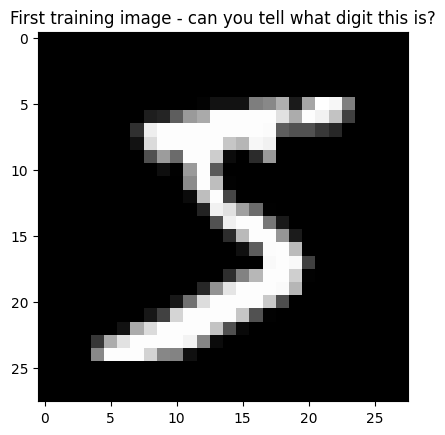

In [11]:
# ============================================================================
# DISPLAYING THE FIRST MNIST IMAGE
# ============================================================================

# Set the default colormap to grayscale
# Without this, matplotlib would use colors which don't make sense for our data
mpl.rcParams['image.cmap'] = 'gray'

# Reshape the flat list into a 28x28 grid and display it
# list(chunks(lst1, 28)) splits 784 values into 28 rows of 28 values each
plt.imshow(list(chunks(lst1, 28)))
plt.title("First training image - can you tell what digit this is?")
plt.show()

**What does the code above do?**

Three things in three lines:

1. `mpl.rcParams['image.cmap'] = 'gray'` switches matplotlib's default colormap to grayscale. Without this, `imshow` would render the pixel values through the default `viridis` colormap (green-to-yellow), which is meaningless for MNIST.
2. `list(chunks(lst1, 28))` reshapes the 784-vector into a 28 × 28 nested list.
3. `plt.imshow(...)` renders that 2-D array as an image, automatically scaling the displayed brightness to the data range.

**What you should see:** a hand-drawn "5" in white on a black background, slightly off-center as MNIST digits often are.

## 1.8 Alternative: `itertools.islice` — a different way to chunk

The standard library's `itertools.islice` does roughly the same job as our `chunks` function but at the iterator level — useful when you don't want to commit a list to memory. Worth knowing because Jeremy uses this idiom in later notebooks.

In [12]:
# ============================================================================
# USING ISLICE FOR EFFICIENT ITERATION
# ============================================================================

from itertools import islice

# Create an iterator from our values
it = iter(vals)

# islice returns an iterator, not a list
# We need to convert it with list() to see the values
print("First 5 values:", list(islice(iter(vals), 5)))

# IMPORTANT: Iterators are "consumed" - once you read values, they're gone!
it = iter(vals)
print("\nDemonstrating iterator consumption:")
print("First call - first 5 values:", list(islice(it, 5)))
print("Second call - next 5 values:", list(islice(it, 5)))
print("Third call - empty (iterator exhausted):", list(islice(it, 5)))

First 5 values: [np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.19140625), np.float32(0.9296875)]

Demonstrating iterator consumption:
First call - first 5 values: [np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.19140625), np.float32(0.9296875)]
Second call - next 5 values: [np.float32(0.98828125), np.float32(0.98828125), np.float32(0.98828125), np.float32(0.98828125), np.float32(0.98828125)]
Third call - empty (iterator exhausted): []


**What does the code above do?**

Demonstrates a crucial gotcha about **iterators**: they have state, and that state advances as you consume them.

- `iter(vals)` wraps the list in an iterator object.
- `islice(it, 5)` returns the *next* 5 items from the iterator's current position.
- After three calls of `list(islice(it, 5))`, the iterator is exhausted — there are only 10 values in `vals` and we've pulled them all. The third call returns `[]`.

This is the difference between iterating a *list* (you can iterate it as many times as you want — each pass starts at the beginning) and iterating an *iterator* (one shot only; once consumed, it's done).

In [ ]:
# ============================================================================
# ANOTHER WAY TO RESHAPE THE IMAGE
# ============================================================================

# This is a more advanced technique using iter() with a sentinel value
# iter(callable, sentinel) keeps calling the function until it returns sentinel

it = iter(lst1)  # Create iterator from the image data

# This creates a list of lists, each inner list has 28 values
# The lambda function grabs 28 values each time
# It stops when the list is empty ([])
img = list(iter(lambda: list(islice(it, 28)), []))

# Display the result
plt.imshow(img)
plt.title("Same image, different method to create it")
plt.show()

**What does the code above do?**

Reshapes the 784-element flat image into a 28 × 28 grid using a slightly mind-bending two-argument form of `iter`:

`iter(callable, sentinel)` builds an iterator that **repeatedly calls `callable()`** and **yields each result** until `callable()` returns `sentinel`, at which point iteration stops.

Here:

- `callable` is the lambda `lambda: list(islice(it, 28))` — pull the next 28 items from `it` and return them as a list.
- `sentinel` is `[]` — when the lambda returns an empty list (because `it` is exhausted), stop.

Wrapping that whole thing in `list(...)` materializes a list of 28-element lists — exactly a 28 × 28 image grid. It does the same job as our `chunks()` helper, just with more standard-library machinery.

The point is purely educational — `chunks()` is friendlier — but this idiom is idiomatic in some older Python code and worth being able to read.

# Explaining `iter(lambda: list(islice(it, 28)), [])`

This is the **two-argument form** of `iter()`, which works differently from the usual single-argument version.

`iter(callable, sentinel)` repeatedly calls `callable()` (with no arguments) and yields each result, stopping when a result equals the `sentinel`. So here it keeps calling the lambda over and over, collecting what it returns, until the lambda returns `[]`.

## Why the lambda

The two-arg `iter` requires a **callable that takes zero arguments**. You can't pass `islice(it, 28)` directly because that's not a callable — it's already an iterator. Wrapping it as `lambda: list(islice(it, 28))` creates a zero-argument function that, each time it's called, pulls the next 28 items from `it` and returns them as a list. The lambda is just the mechanism to make "grab 28 more items" something `iter` can call repeatedly.

## Why the `[]`

That's the **sentinel**. When `it` is exhausted, `islice(it, 28)` yields nothing, so `list(...)` returns an empty list `[]`. `iter` compares each returned value against the sentinel `[]`, and when they're equal it stops. So `[]` signals "the source ran out, stop iterating."

## How they work together

Each call to the lambda consumes a chunk of 28 from the stream `it`. `iter` keeps calling it and yielding those 28-element chunks until a call returns `[]`, at which point iteration halts. The outer `list(...)` collects all the chunks.

The net effect is **chunking**: if `it` is a flat stream of pixels, this splits it into rows of 28, giving a list of 28-element rows (one row of a 28×28 image per call).

## A more readable equivalent

```python
img = []
while True:
    row = list(islice(it, 28))
    if row == []:
        break
    img.append(row)
```

The one-liner does the same thing using `iter`'s sentinel feature instead of an explicit loop.

---

# Part 2: From Lists of Lists to PyTorch Tensors

## Why does this transition matter?

So far our "image" has been a list of lists — pure Python. That's enough to display one digit, but it's catastrophically slow once we want to do real numerical work on thousands of images. Every Python attribute lookup, every `[]` index, every `+` operator carries dynamic-typing overhead.

PyTorch tensors are stored as **contiguous blocks of typed memory** with vectorized C/CUDA kernels operating on them. The same operation that takes ~50 ms in pure Python takes ~50 µs as a tensor op — *thousand-fold* speedups before you've even left the CPU.

This part introduces tensors gently — first as a cleaner indexing experience, then as the data primitive that the rest of the course is built on.

---

## 2.1 Accessing elements in a list of lists

In [ ]:
# ============================================================================
# ACCESSING ELEMENTS IN A 2D LIST (MATRIX-LIKE)
# ============================================================================

# Our image is stored as a list of lists (like a matrix)
# To access element at row 20, column 15:
print(f"Pixel value at row 20, column 15: {img[20][15]}")
print()
print("Note: This uses two separate indexing operations: img[20] then [15]")
print("This is how Python lists work, but it's not as clean as matrix notation")

**What does the code above do?**

Pulls the pixel value at row 20, column 15 of the 28 × 28 nested list. Notice the awkward double-bracket syntax: `img[20][15]`. That's two separate operations — `img[20]` first returns the row (a 28-element list), then `[15]` indexes into that.

It works, but it forces you to think of a matrix as "a list of rows," which is one valid mental model but not the cleanest one. The next subsection builds a tiny Matrix class so we can write `m[20, 15]` instead.

## 2.2 A toy `Matrix` class for cleaner indexing

In [ ]:
# ============================================================================
# A SIMPLE MATRIX CLASS
# ============================================================================

class Matrix:
    """
    A simple wrapper around a list of lists that provides matrix-style indexing.

    Instead of: my_list[row][col]
    We can use: my_matrix[row, col]
    """

    def __init__(self, xs):
        """
        Initialize the matrix with data.

        Args:
            xs: A list of lists (2D data)
        """
        self.xs = xs  # Store the data

    def __getitem__(self, idxs):
        """
        Get an item using matrix notation: matrix[row, col]

        Args:
            idxs: A tuple of (row_index, column_index)

        Returns:
            The value at that position
        """
        # idxs is a tuple like (20, 15)
        # idxs[0] is the row, idxs[1] is the column
        return self.xs[idxs[0]][idxs[1]]

# Create a Matrix from our image and access an element
m = Matrix(img)
print(f"Using our Matrix class: m[20, 15] = {m[20, 15]}")
print(f"Much cleaner than: img[20][15] = {img[20][15]}")

**What does the code above do?**

Defines a class with a single piece of magic: a custom `__getitem__` method.

When Python sees `m[20, 15]`, it interprets the **comma inside the brackets** as a tuple — so the call is really `m.__getitem__((20, 15))`. Our class catches that tuple, splits it into `row, col`, and does the usual `self.xs[row][col]`.

It's three lines of plumbing that buys us math-textbook indexing notation. PyTorch tensors give us the same thing for free, but the pattern of using `__getitem__` to repurpose `[]` shows up constantly in the course — `DataLoader[i]`, `Learner[name]`, callback registries, etc. Worth seeing in isolation.

## 2.3 PyTorch tensors — the real workhorse

PyTorch tensors are the data primitive for the rest of the course. They are:

- **Typed contiguous memory** (no Python object overhead per element).
- **Operated on by vectorized C++/CUDA kernels** (no Python loop per element).
- **GPU-aware** (one `.cuda()` call moves them to the graphics card).
- **Differentiable** (we'll exploit this for backprop starting in notebook 03).

For this notebook we only need the first three properties. Autograd waits until notebook 03.

In [ ]:
# ============================================================================
# INTRODUCING PYTORCH TENSORS
# ============================================================================

import torch                # The main PyTorch library
from torch import tensor    # Shortcut to create tensors

# Creating a simple 1D tensor (vector)
simple_tensor = tensor([1, 2, 3])
print("A simple 1D tensor:", simple_tensor)
print(f"Type: {type(simple_tensor)}")

**What does the code above do?**

Imports PyTorch and creates a one-dimensional tensor from a list of three numbers.

- `import torch` brings in the PyTorch namespace.
- `from torch import tensor` gives us the factory function `tensor(...)` directly. The same as calling `torch.tensor([1, 2, 3])` but shorter.
- `tensor([1, 2, 3])` infers the dtype as `int64` (because the inputs are Python ints) and allocates a small chunk of CPU memory holding the three values back-to-back.

`type(simple_tensor)` confirms it's a `torch.Tensor` instance — not a list, not a NumPy array.

In [ ]:
# ============================================================================
# CONVERTING OUR DATA TO PYTORCH TENSORS
# ============================================================================

# Convert all our numpy arrays to PyTorch tensors
# map() applies the tensor function to each item
x_train, y_train, x_valid, y_valid = map(tensor, (x_train, y_train, x_valid, y_valid))

# Check the shape of our training data
print(f"Shape of x_train: {x_train.shape}")
print()
print("What does this mean?")
print("  - First number (50000): We have 50,000 training images")
print("  - Second number (784): Each image has 784 pixel values (28 x 28 = 784)")

**What does the code above do?**

Converts all four NumPy arrays into PyTorch tensors in one line using `map`. After this cell, every `x_train`, `y_train`, etc. is a `torch.Tensor` — the original NumPy arrays are gone (`map` returns new objects; the names are rebound).

`x_train.shape` reports `(50000, 784)` — a 2-D tensor with 50,000 rows and 784 columns. The shape attribute returns a `torch.Size`, which behaves like a tuple but with a few extras.

In [ ]:
# ============================================================================
# TENSOR PROPERTIES AND METHODS
# ============================================================================

# Check the data type
print(f"Data type: {x_train.type()}")
print("FloatTensor means these are floating-point (decimal) numbers")

**What does the code above do?**

Reports the underlying numeric type. `FloatTensor` means 32-bit floating point (`float32`), which is the default for `tensor(...)` when the inputs are floats. Other common dtypes you'll see:

| Dtype | Use case |
|---|---|
| `torch.float32` (a.k.a. `FloatTensor`) | Default for everything — features, weights, activations |
| `torch.float16` / `torch.bfloat16` | Mixed-precision training (notebook 17) |
| `torch.int64` (`LongTensor`) | Class labels, integer indices |
| `torch.uint8` | Raw image bytes (PIL load), boolean masks |
| `torch.bool` | Mask tensors from comparisons like `x > 0` |

## 2.4 Reshaping tensors

`reshape` lets us re-interpret a contiguous block of memory as a different shape *without copying the underlying data*. A 50,000 × 784 tensor and a 50,000 × 28 × 28 tensor pointing at the same memory are different "views" of the same 39,200,000 floats.

In [ ]:
# ============================================================================
# RESHAPING TENSORS
# ============================================================================

# Reshape from (50000, 784) to (50000, 28, 28)
# -1 tells PyTorch to figure out the right number automatically
imgs = x_train.reshape((-1, 28, 28))

print(f"Original shape: {x_train.shape}")
print(f"New shape: {imgs.shape}")
print()
print("Now we have:")
print("  - 50,000 images")
print("  - Each image is 28 rows")
print("  - Each row has 28 columns")

**What does the code above do?**

Re-interprets the (50000, 784) flat tensor as a (50000, 28, 28) image tensor. The `-1` in `reshape((-1, 28, 28))` is a "figure-it-out-for-me" placeholder: PyTorch sees that two of the three dimensions are 28, and the total element count is 50000 × 784 = 39200000, so the unknown dimension must be 39200000 / (28 × 28) = 50000.

No data is moved — `imgs` and `x_train` point at the same memory; only the stride information differs. That's why reshape is essentially free (microseconds, not milliseconds).

In [ ]:
# ============================================================================
# DISPLAYING A TENSOR IMAGE
# ============================================================================

# Now we can display directly - no need for our chunks() function!
plt.imshow(imgs[0])
plt.title(f"First training image (digit: {y_train[0].item()})")
plt.show()

**What does the code above do?**

Displays the first reshaped image. Notice we can pass `imgs[0]` directly to `plt.imshow` now — no more `list(chunks(...))` ceremony. Tensors talk to matplotlib natively.

**What you should see:** the same "5" from §1.7, but the title also reports the ground-truth label from `y_train[0]`. `.item()` extracts the Python int from a zero-dimensional tensor.

In [ ]:
# ============================================================================
# TENSOR INDEXING - MULTIPLE DIMENSIONS AT ONCE
# ============================================================================

# With tensors, we can index all dimensions at once!
# imgs[image_index, row, col]
print(f"Value at image 0, row 20, col 15: {imgs[0, 20, 15]}")

# This is cleaner than imgs[0][20][15]

**What does the code above do?**

Demonstrates multi-axis tensor indexing: `imgs[0, 20, 15]` — read as "image 0, row 20, column 15." All three indices go inside *one* set of brackets. Compare with the lists-of-lists version `img[0][20][15]`, which requires three separate `__getitem__` calls.

This isn't just cleaner syntax — under the hood, the tensor index is computed in a single C call instead of bouncing through three Python object lookups.

In [ ]:
# ============================================================================
# EXPLORING THE LABELS
# ============================================================================

# n = number of samples, c = number of features per sample
n, c = x_train.shape
print(f"Number of training samples: {n}")
print(f"Number of features (pixels) per sample: {c}")

# Look at the labels
print(f"\nAll labels: {y_train}")
print(f"Shape of labels: {y_train.shape}")

**What does the code above do?**

Destructures the 2-D shape `(50000, 784)` into two named variables, `n` and `c`:

- `n` = 50,000 — the number of training samples.
- `c` = 784 — the number of features (pixels) per sample.

Then prints the labels and their shape. `y_train.shape` is just `(50000,)` — a 1-D tensor of length 50,000 — because each image has exactly one label.

The variable names `n` and `c` are conventional: **n** for "number of examples," **c** for "channels/features." We'll see them again.

In [ ]:
# ============================================================================
# FINDING MIN AND MAX VALUES
# ============================================================================

# Two ways to find min and max of labels:

# Method 1: Python's built-in functions
print(f"Min label (Python min): {min(y_train)}")
print(f"Max label (Python max): {max(y_train)}")

# Method 2: Tensor methods (preferred - faster for large tensors)
print(f"Min label (tensor method): {y_train.min()}")
print(f"Max label (tensor method): {y_train.max()}")

print("\nThis confirms our labels are digits 0-9!")

**What does the code above do?**

Compares two ways to compute min/max:

- `min(y_train)` / `max(y_train)` — Python's built-in functions, which iterate over the tensor element-by-element in Python. Slow for large tensors.
- `y_train.min()` / `y_train.max()` — tensor methods that call into a vectorized C kernel. Fast.

Both return the same answer (0 and 9), but the tensor methods are dramatically faster on big tensors. Get in the habit of using `.min()` / `.max()` / `.sum()` / `.mean()` on tensors; reach for the Python built-ins only when you really need Python-list semantics.

---

# Part 3: Random Numbers — How `torch.randn` Actually Works

## Why a digression on RNGs?

Diffusion models, neural network initialization, dropout, data augmentation — they all depend on a steady supply of random numbers. But computers are deterministic; they can't produce *true* randomness without specialized hardware. They use **pseudo-random number generators (PRNGs)**: deterministic functions of an internal state that produce sequences indistinguishable from random for practical purposes.

Understanding the PRNG you depend on matters because:

1. **Reproducibility.** A seed lets you replay the exact same "random" sequence. Critical for debugging and for papers that should be reproducible.
2. **Quality.** Bad PRNGs have patterns — repeating cycles, correlations between successive draws — that can poison your experiment.
3. **Speed.** Producing the random numbers themselves can become a bottleneck if you're not careful.

We'll build a toy PRNG from scratch (Wichmann–Hill, an algorithm from the 1980s) so you see one all the way through. Then we'll benchmark it against PyTorch's built-in generator and see why "writing your own" is a learning exercise, not a production move.

---

## 3.1 The Wichmann–Hill algorithm

In [ ]:
# ============================================================================
# IMPLEMENTING A SIMPLE RANDOM NUMBER GENERATOR
# ============================================================================

# This is the Wichmann-Hill algorithm, used in Python before version 2.3
# It demonstrates how pseudo-random numbers work

# Global variable to store the current state
rnd_state = None

def seed(a):
    """
    Initialize the random number generator with a seed.

    The same seed always produces the same sequence of "random" numbers.
    This is important for reproducibility in machine learning experiments!

    Args:
        a: The seed value (any integer)
    """
    global rnd_state
    # divmod(x, y) returns (x // y, x % y) - quotient and remainder
    # We use this to split our seed into three separate state values
    a, x = divmod(a, 30268)  # x is remainder when divided by 30268
    a, y = divmod(a, 30306)
    a, z = divmod(a, 30322)
    # Each state value must be at least 1
    rnd_state = int(x)+1, int(y)+1, int(z)+1

# Set a seed and see the initial state
seed(457428938475)
print(f"Initial random state: {rnd_state}")

**What does the code above do?**

Initializes a three-part state from a single user-supplied seed. The Wichmann–Hill algorithm combines three independent linear congruential generators (LCGs); the seed needs to be split into three starting states.

`divmod(a, b)` returns the quotient and the remainder as a tuple. We use it three times to peel off three pieces of the seed, modulo three different primes (well, three coprime numbers). The `+1` is a fix to ensure none of the states is zero — an LCG seeded with zero gets stuck producing zero forever.

After this cell, `rnd_state` is a tuple `(x, y, z)` of three positive integers ready to be evolved.

In [ ]:
# ============================================================================
# THE RANDOM NUMBER GENERATION FUNCTION
# ============================================================================

def rand():
    """
    Generate a random number between 0 and 1.

    Each call updates the internal state and returns a new "random" number.
    The sequence is completely deterministic - same state = same output.

    Returns:
        A float between 0 and 1
    """
    global rnd_state
    x, y, z = rnd_state

    # Update each state variable using modular arithmetic
    # These specific numbers were carefully chosen to produce good randomness
    x = (171 * x) % 30269
    y = (172 * y) % 30307
    z = (170 * z) % 30323

    # Save the new state
    rnd_state = x, y, z

    # Combine the three values and take the fractional part
    return (x/30269 + y/30307 + z/30323) % 1.0

# Generate a few random numbers
print("Three 'random' numbers:", rand(), rand(), rand())

# If we reset the seed, we get the same sequence!
seed(457428938475)
print("After resetting seed:", rand(), rand(), rand())

**What does the code above do?**

Each call to `rand()` evolves the three state variables independently and combines them into a single float in `[0, 1)`. The three update rules:

- $x \leftarrow (171 \cdot x) \mod 30269$
- $y \leftarrow (172 \cdot y) \mod 30307$
- $z \leftarrow (170 \cdot z) \mod 30323$

are classic linear congruential generators. The multipliers (171, 172, 170) and moduli (30269, 30307, 30323) were chosen so that each individual stream has a long period and the three combined streams produce decent statistical randomness.

The return value `(x/30269 + y/30307 + z/30323) % 1.0` takes the fractional part of the sum of three numbers each in `[0, 1)`. The `% 1.0` keeps the result strictly less than 1.

The bottom four lines demonstrate **determinism**: re-seeding with the same value rewinds the whole sequence.

In [ ]:
# ============================================================================
# VISUALIZING RANDOM NUMBERS
# ============================================================================

# Plot 50 random numbers to see how "random" they look
plt.plot([rand() for _ in range(50)])
plt.title("50 Random Numbers - should look unpredictable")
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()

**What does the code above do?**

Plots 50 successive draws against their index. If the generator is doing its job, the line should look like noise — no obvious trend, no repeating pattern.

**What you should see:** a jagged line bouncing around the middle of the `[0, 1]` range with no visible structure.

In [ ]:
# ============================================================================
# CHECKING THE DISTRIBUTION
# ============================================================================

# A good random number generator produces uniformly distributed values
# Let's generate 10,000 numbers and see if they're evenly spread

plt.hist([rand() for _ in range(10000)], bins=20)
plt.title("Histogram of 10,000 Random Numbers")
plt.xlabel("Value")
plt.ylabel("Count")
plt.show()

print("A uniform distribution should have roughly equal bars!")

**What does the code above do?**

Drops 10,000 draws into a 20-bin histogram. If the generator's marginal distribution is uniform on `[0, 1]`, every bin should be roughly equally tall (500 ± noise per bin).

**What you should see:** twenty bars of roughly the same height. Wichmann–Hill is good enough that the variation is just statistical noise.

A *bad* generator would show systematic gaps or peaks — values clustered in some part of the range. This was actually a common bug in older RNGs; one famous example, RANDU, had outputs that all fell on 15 hyperplanes in 3-D space.

In [ ]:
# ============================================================================
# SPEED COMPARISON: OUR GENERATOR VS PYTORCH
# ============================================================================

# Generate 7840 random numbers with our slow method
%timeit -n 10 list(chunks([rand() for _ in range(7840)], 10))

# Generate with PyTorch (much faster!)
%timeit -n 10 torch.randn(784, 10)

print("\nPyTorch is MUCH faster because:")
print("1. It's written in C++ (compiled, not interpreted)")
print("2. It uses optimized CPU instructions")
print("3. It can use parallel processing")

**What does the code above do?**

Times two ways to generate 7840 random numbers (the right amount for one mini-batch of 10 MNIST images):

1. Our Python `rand()` called 7840 times in a list comprehension, then passed to `chunks` to reshape — pure interpreted Python from top to bottom.
2. `torch.randn(784, 10)` — one call into a compiled C kernel that fills 7840 normally distributed floats.

The PyTorch call is ~1000× faster, and it doesn't even share the same distribution (PyTorch gives you a *normal* `N(0, 1)` while our `rand()` gives uniform `U(0, 1)`). The lesson: in production, **never roll your own RNG.** You'll lose speed and statistical quality both. The Wichmann–Hill exercise was for understanding — `torch.randn` is for actual use.

---

# Part 4: Matrix Multiplication — The Naive Triple Loop

## Setting the stage

This is the canonical operation. Given a matrix $A$ of shape $(M, K)$ and a matrix $B$ of shape $(K, N)$, the product $C = AB$ has shape $(M, N)$ and is defined elementwise by

$$C_{ij} = \sum_{k=0}^{K-1} A_{ik}\, B_{kj}.$$

The formula is the universe in a teaspoon — every fast implementation in this notebook computes exactly this, just with different ways of organizing the work.

For our running example:

- $A$ = the first 5 validation images, shape (5, 784). Think of each row as an image.
- $B$ = a randomly initialized weight matrix, shape (784, 10). Think of each column as a "class detector" for one of the 10 digits.
- $C = AB$ has shape (5, 10) — five rows of ten "scores," one score per (image, class) pair.

This is exactly the linear layer of a one-layer digit classifier. We're not training it (the weights are random), but the *shapes* and *operations* are identical to what a neural network does. Get matmul right and you have the spine of the entire course.

---

## 4.1 Setting up weights and inputs

In [ ]:
# ============================================================================
# SETTING UP FOR MATRIX MULTIPLICATION
# ============================================================================

# Set a random seed for reproducibility
# This ensures we get the same "random" weights every time
torch.manual_seed(1)

# Create random weights: 784 inputs -> 10 outputs
# This is like a simple neural network layer for classifying digits!
weights = torch.randn(784, 10)  # 784 input features, 10 output classes

# Create a bias term (starts as zeros)
bias = torch.zeros(10)

print(f"Weights shape: {weights.shape}")
print(f"Bias shape: {bias.shape}")
print()
print("These weights would multiply our 784 pixel values to produce")
print("10 output values - one for each digit class (0-9)!")

**What does the code above do?**

`torch.manual_seed(1)` pegs PyTorch's global RNG so the next `torch.randn` call returns the same values every time you run the cell. This is the standard reproducibility incantation.

`torch.randn(784, 10)` draws 7840 numbers from `N(0, 1)` and reshapes them into a 784 × 10 matrix. This is one of the standard initialization tricks for neural network weights — start small and Gaussian. We'll dig much deeper into initialization in notebook 11.

`torch.zeros(10)` is the bias term for our (untrained) classifier — a 10-vector of zeros. We won't actually use the bias in the matmul, but it's natural to introduce it alongside the weights.

In [ ]:
# ============================================================================
# PREPARING OUR INPUT DATA
# ============================================================================

# Let's work with just 5 images for now (easier to understand)
m1 = x_valid[:5]   # 5 images, each with 784 pixels
m2 = weights       # Our weight matrix

print(f"Input matrix (m1) shape: {m1.shape}")
print(f"Weight matrix (m2) shape: {m2.shape}")
print()
print("Matrix multiplication rule: (A x B) requires A's columns = B's rows")
print(f"m1 has {m1.shape[1]} columns, m2 has {m2.shape[0]} rows - they match!")
print(f"Result will be: ({m1.shape[0]} x {m2.shape[1]}) = (5 x 10)")

**What does the code above do?**

Picks out the first five validation images as our running input matrix `m1`. Five is small enough that the naive triple loop will finish in under a second, but large enough that broadcasting will visibly help later.

`x_valid[:5]` is standard NumPy-style slicing: rows 0 through 4 inclusive, all columns. Shape: (5, 784).

The print statement is doing the matmul-compatibility check by hand: $A$'s number of *columns* (784) must equal $B$'s number of *rows* (784). Output shape is $A$'s rows × $B$'s columns = (5, 10).

In [ ]:
# ============================================================================
# EXTRACTING DIMENSIONS
# ============================================================================

# Get the dimensions of our matrices
ar, ac = m1.shape  # ar = "a rows", ac = "a columns"
br, bc = m2.shape  # br = "b rows", bc = "b columns"

print(f"Matrix m1: {ar} rows x {ac} columns")
print(f"Matrix m2: {br} rows x {bc} columns")
print(f"Result will be: {ar} rows x {bc} columns")

**What does the code above do?**

Destructures the shapes into named variables we'll use in the loop bounds:

- `ar`, `ac` = 5, 784 (`A` rows, `A` columns)
- `br`, `bc` = 784, 10 (`B` rows, `B` columns)

The convention `Xr, Xc` for "rows and columns of matrix X" appears throughout the rest of the course.

## 4.2 Matmul as three nested loops

In [ ]:
# ============================================================================
# MATRIX MULTIPLICATION: THE NAIVE WAY (3 NESTED LOOPS)
# ============================================================================

# Create a result matrix filled with zeros
t1 = torch.zeros(ar, bc)
print(f"Result matrix shape: {t1.shape}")

# The three nested loops
for i in range(ar):         # For each row in m1 (5 rows)
    for j in range(bc):     # For each column in m2 (10 columns)
        for k in range(ac): # For each element to multiply (784 elements)
            # Add the product to the running sum
            t1[i,j] += m1[i,k] * m2[k,j]

print("Matrix multiplication complete!")

**What does the code above do?**

The literal translation of the math:

$$C_{ij} = \sum_{k=0}^{K-1} A_{ik}\, B_{kj}.$$

into three nested Python loops:

```
for each row i of A:           # outer loop:  M iterations
    for each column j of B:    # middle loop: N iterations
        for each k:            # inner loop:  K iterations
            C[i,j] += A[i,k] * B[k,j]
```

For our 5 × 784 by 784 × 10 example, that's 5 × 10 × 784 = **39,200** iterations of the innermost line. Each iteration is a Python multiplication and an in-place tensor add — both expensive in the interpreter.

This implementation is correct. It's also catastrophically slow. The rest of Parts 5–9 are six progressively cleverer ways to do the exact same calculation.

In [ ]:
# ============================================================================
# LOOKING AT THE RESULT
# ============================================================================

# Set display options for cleaner output
torch.set_printoptions(precision=2, linewidth=140, sci_mode=False)

print("Result of multiplying 5 images by our weight matrix:")
print(t1)
print()
print(f"Shape: {t1.shape}")
print()
print("Each row is one image transformed into 10 numbers")
print("(one for each digit class)")

**What does the code above do?**

Lowers the float display precision (2 decimal places, 140-char line width, no scientific notation) so the output matrix is readable, then prints it. Each row of the 5 × 10 output is one image's "class scores" — a vector of 10 numbers, one per digit class.

The values look meaningless because the weights are random — we haven't trained anything. But the *shape* (5, 10) and the *operation* (one matmul per layer) are exactly what a one-layer neural network classifier does in the wild.

## 4.3 Reusable `matmul(a, b)` function

In [ ]:
# ============================================================================
# CREATING A REUSABLE FUNCTION
# ============================================================================

import numpy as np
np.set_printoptions(precision=2, linewidth=140)

def matmul(a, b):
    """
    Multiply two matrices using the naive triple-loop method.

    Args:
        a: First matrix with shape (ar, ac)
        b: Second matrix with shape (br, bc)
           Note: ac must equal br for valid multiplication!

    Returns:
        Result matrix with shape (ar, bc)
    """
    # Get dimensions
    (ar, ac), (br, bc) = a.shape, b.shape

    # Create result matrix
    c = torch.zeros(ar, bc)

    # Triple nested loop
    for i in range(ar):
        for j in range(bc):
            for k in range(ac):
                c[i,j] += a[i,k] * b[k,j]

    return c

# Test that our function gives the same result
result = matmul(m1, m2)
print("Our function produces the same result:", torch.allclose(t1, result))

**What does the code above do?**

Wraps the triple loop in a function with a docstring. Identical logic to §4.2; nothing new computationally. The reason to bother: we'll re-define `matmul` six more times in this notebook with different implementations and a common signature, so user code can swap implementations without changing.

The `torch.allclose(t1, result)` check verifies the function's output matches what we computed step-by-step in §4.2 — a sanity check that the refactor didn't introduce bugs.

In [ ]:
# ============================================================================
# TIMING THE NAIVE METHOD
# ============================================================================

# Let's see how slow this is
%time _ = matmul(m1, m2)

# Count total operations
total_ops = ar * bc * ac
print(f"\nTotal multiplication operations: {total_ops:,}")
print("That's about 40,000 multiplications for just 5 images!")
print("Imagine doing this for 50,000 images...")

**What does the code above do?**

`%time` is a Jupyter line magic that reports how long the line takes to execute. For the naive triple loop on 5 images, expect somewhere around 500 ms — half a second of Python interpreter overhead grinding through 39,200 multiplications.

The print statement does the projection: if 39,200 multiplications take 500 ms, then 50,000 × 10 × 784 = 392,000,000 multiplications would take ~5,000 seconds. **More than an hour.** That's the disaster we're about to solve.

---

# Part 5: First Speedup — Numba-Compiled Dot Product

## Where the time is going

The triple loop in §4 is slow for one specific reason: **the Python interpreter pays a constant per-operation tax** (type checking, attribute lookups, object boxing/unboxing). For a simple operation like `c[i,j] += a[i,k] * b[k,j]`, that tax can be 50× the cost of the actual arithmetic.

The interpreter tax is paid most often by the **innermost** loop, because that's the one that runs the most times. If we can compile that loop to machine code — skipping Python entirely for those 784 iterations — we get most of the win without rewriting the whole function.

## Numba in one paragraph

**Numba** is a just-in-time (JIT) compiler for Python. You decorate a function with `@njit` and on its first call Numba inspects the types, generates LLVM IR, and compiles to native machine code. Subsequent calls run the compiled version, which is typically 10–100× faster than interpreted Python.

The catch: Numba only supports a subset of Python and NumPy. Anything fancy (custom classes, Python data structures other than tuples/lists/arrays) won't compile. For numerical inner loops this is fine — that's exactly the kind of code Numba is good at.

---

## 5.1 A Numba-compiled dot product

In [ ]:
# ============================================================================
# USING NUMBA TO SPEED UP DOT PRODUCTS
# ============================================================================

from numba import njit  # njit = "no Python" JIT - the fastest mode

@njit  # This decorator tells Numba to compile this function
def dot(a, b):
    """
    Compute the dot product of two vectors.

    A dot product multiplies corresponding elements and sums them:
    dot([1,2,3], [4,5,6]) = 1*4 + 2*5 + 3*6 = 32

    Args:
        a: First vector (1D array)
        b: Second vector (1D array) - must be same length as a

    Returns:
        A single number (the dot product)
    """
    res = 0.
    for i in range(len(a)):
        res += a[i] * b[i]
    return res

**What does the code above do?**

Defines a textbook dot product — multiply corresponding elements, sum them up — and decorates it with `@njit`. The decorator tells Numba: "compile this to native code on first call; don't fall back to interpreted Python."

The function itself is pure: it takes two 1-D arrays and returns a scalar. No PyTorch tensors here — Numba speaks NumPy, not PyTorch. We'll pay the (cheap) cost of converting tensors to NumPy arrays at the call site in §5.3.

`njit` is shorthand for "no Python" JIT — meaning Numba will refuse to fall back to interpreted Python if it can't compile a line. This catches bugs early; a permissive fallback would silently nerf your speedup.

In [ ]:
# ============================================================================
# TESTING NUMBA - FIRST CALL VS SECOND CALL
# ============================================================================

from numpy import array

# First call - includes compilation time (slow!)
print("First call (includes compilation):")
%time dot(array([1., 2, 3]), array([2., 3, 4]))

# Second call - uses compiled version (fast!)
print("\nSecond call (already compiled):")
%time dot(array([1., 2, 3]), array([2., 3, 4]))

print("\nThe second call is MUCH faster because the code is already compiled!")

**What does the code above do?**

Demonstrates the JIT compilation pattern. The **first** call to `dot(...)` is slow — possibly 1+ second — because Numba is compiling the function. The **second** call uses the cached compiled artifact and runs in microseconds.

This compile-on-first-call behavior matters in practice: don't benchmark a Numba function on its first call (or you'll measure compilation, not execution). Always do a warmup call before timing.

## 5.2 Use the fast dot product inside matmul

In [ ]:
# ============================================================================
# FASTER MATRIX MULTIPLICATION WITH NUMBA DOT PRODUCT
# ============================================================================

def matmul(a, b):
    """
    Matrix multiplication using Numba-accelerated dot products.

    Only 2 Python loops now - the innermost loop is compiled!
    """
    (ar, ac), (br, bc) = a.shape, b.shape
    c = torch.zeros(ar, bc)

    for i in range(ar):
        for j in range(bc):
            # a[i,:] gets all columns in row i (a vector)
            # b[:,j] gets all rows in column j (a vector)
            # dot() computes their dot product
            c[i,j] = dot(a[i,:], b[:,j])

    return c

**What does the code above do?**

The same matmul as before, but the inner loop is now replaced by `dot(a[i,:], b[:,j])`. Two Python loops remain (i and j), but the K-loop — the one that ran 784 times per output element — is now a single function call into compiled code.

This is what "vectorization" looks like at its simplest: push the loops inward so the inner ones run in compiled code while only the outer ones pay the interpreter tax.

In [ ]:
# ============================================================================
# TESTING THE NUMBA VERSION
# ============================================================================

# Convert to numpy arrays (Numba works with numpy)
m1a, m2a = m1.numpy(), m2.numpy()

# Import test helper
from fastcore.test import *

# Verify we get the same result
test_close(t1, matmul(m1a, m2a))
print("Results match!")

# Time it
%timeit -n 50 matmul(m1a, m2a)

print("\nMuch faster than pure Python!")

**What does the code above do?**

`m1.numpy()` and `m2.numpy()` convert the PyTorch tensors to NumPy arrays — Numba's expected input type. This conversion is a zero-copy view on the same underlying memory, so it's effectively free.

`from fastcore.test import *` brings in `test_close`, which asserts that two tensors are equal within a tolerance. We use it to verify that the Numba matmul produces the same answer as the naive one — important sanity check, because nothing else catches "you accidentally swapped indices."

`%timeit -n 50` runs the call 50 times and reports the average. Expect ~5 ms — about 100× faster than the naive ~500 ms.

---

# Part 6: Broadcasting — Eliminating Loops by Shape

We just shrank the inner loop. Can we kill the middle loop too? Yes, and the tool for the job is **broadcasting**.

This is the most important concept in tensor programming. Half of all PyTorch shape errors are broadcasting misunderstandings. The other half are forgetting that broadcasting *just happened*. We're going to dwell on it.

## 6.1 Elementwise operations — the warm-up

In [ ]:
# ============================================================================
# ELEMENTWISE OPERATIONS IN ACTION
# ============================================================================

# Create two simple tensors
a = tensor([10., 6, -4])
b = tensor([2., 8, 7])
print(f"a = {a}")
print(f"b = {b}")

# Addition - adds corresponding elements
print(f"\na + b = {a + b}")

# What about comparison?
print(f"\na < b = {a < b}")  # Element-by-element comparison

# Computing the fraction of elements where a < b
print(f"\nFraction where a < b: {(a < b).float().mean()}")

**What does the code above do?**

Demonstrates that tensor `+` is **elementwise**: position 0 of `a` adds to position 0 of `b`, position 1 adds to position 1, etc. Same shape in, same shape out.

The comparison `a < b` is also elementwise, returning a boolean tensor. `(a < b).float().mean()` then converts the booleans to floats (True → 1.0, False → 0.0) and averages — giving you the *fraction* of positions where `a < b`. This idiom of "convert mask to float, take mean" is a common way to express "what percent of these are true?".

In [ ]:
# ============================================================================
# OPERATIONS ON MATRICES
# ============================================================================

# Create a 3x3 matrix
m = tensor([[1., 2, 3],
            [4, 5, 6],
            [7, 8, 9]])
print("Matrix m:")
print(m)

# Compute the Frobenius norm (a way to measure the "size" of a matrix)
# Formula: sqrt(sum of all elements squared)
sum_of_squares = (m * m).sum()  # m*m is elementwise multiplication
frobenius_norm = sum_of_squares.sqrt()

print(f"\nSum of squares: {sum_of_squares}")
print(f"Frobenius norm: {frobenius_norm}")

**What does the code above do?**

Computes the **Frobenius norm** of a matrix — the square root of the sum of all element-squares. It's the natural matrix generalization of vector length: $\|M\|_F = \sqrt{\sum_{i,j} M_{ij}^2}$.

`m * m` is elementwise (each element squared); `.sum()` reduces to a scalar; `.sqrt()` takes the square root. Three tensor calls, one math identity.

This is also the natural loss function for the "L2 distance between two matrices" — we'll see exactly this in the DDPM loss (notebook 15).

## 6.2 Slicing tensors

In [ ]:
# ============================================================================
# SLICING EXAMPLES
# ============================================================================

print("Matrix m:")
print(m)

# Get a row
print(f"\nRow 2 (m[2,:] or m[2]): {m[2,:]}")

# Get a column
print(f"Column 2 (m[:,2]): {m[:,2]}")

# Note: m[2] is shorthand for m[2,:]
print(f"\nm[2] is the same as m[2,:]: {torch.equal(m[2], m[2,:])}")

**What does the code above do?**

Demonstrates three common slicing idioms:

| Syntax | Meaning |
|---|---|
| `m[2]` | The whole row at index 2. Shorthand for `m[2, :]`. |
| `m[2, :]` | Row 2 explicitly — same as above. |
| `m[:, 2]` | Column 2 — `:` means "all rows," `2` picks the column. |
| `m[1:3, 0:2]` | A submatrix: rows 1–2, columns 0–1 (the upper-left 2×2 block, shifted down one row). |

`torch.equal(m[2], m[2,:])` returns `True` — confirming that the two notations refer to the same row.

Slicing returns a **view** (not a copy) on the original tensor's memory. Modifying a slice modifies the original — a common foot-gun for newcomers.

## 6.3 Broadcasting — a first example

In [ ]:
# ============================================================================
# BROADCASTING IN ACTION
# ============================================================================

# A vector
c = tensor([10., 20, 30])
print(f"Vector c: {c}")

# A matrix
m = tensor([[1., 2, 3],
            [4, 5, 6],
            [7, 8, 9]])
print(f"\nMatrix m:")
print(m)

# Broadcasting: c is added to EACH ROW of m
print(f"\nm + c (c broadcasts to each row):")
print(m + c)

print("\nPyTorch automatically 'copied' c to match m's shape!")

**What does the code above do?**

Adds a 1-D vector `c` (shape `(3,)`) to a 2-D matrix `m` (shape `(3, 3)`). The shapes don't match, but PyTorch **broadcasts** — automatically replicating `c` along the missing dimension so that the addition makes sense.

The result is the matrix you'd get by adding `c` to *every row* of `m`:

```
   row 0:    [1, 2, 3] + [10, 20, 30] = [11, 22, 33]
   row 1:    [4, 5, 6] + [10, 20, 30] = [14, 25, 36]
   row 2:    [7, 8, 9] + [10, 20, 30] = [17, 28, 39]
```

Crucially, PyTorch does **not** actually copy `c` three times in memory. It just adjusts the strides so that the broadcast happens implicitly — the kernel reads `c` once per column regardless of how many rows are involved. Broadcasting is a *zero-copy* trick on top of well-designed kernels.

---

# Deep Dive: Broadcasting

Broadcasting is the single most important shape-manipulation technique in tensor programming. It's worth a long, slow look — because once you have it in your bones, you'll find yourself writing matmuls, attention mechanisms, and loss functions without a single explicit loop.

---

## The Problem Broadcasting Solves

You want to add a per-feature bias to every row of a batch of activations. Or scale every column of a matrix by its corresponding standard deviation. Or compute pairwise distances between two sets of points. The naive way:

```python
# Add bias to every row of activations
for i in range(batch_size):
    for j in range(num_features):
        out[i, j] = activations[i, j] + bias[j]
```

You'd need an explicit loop because the shapes don't match: activations is `(B, F)`, bias is `(F,)`. Broadcasting eliminates the loop:

```python
out = activations + bias   # shapes (B, F) + (F,) → (B, F)
```

That's it. The single `+` runs a vectorized kernel that visits every (i, j) once — the way the loop would have, but in compiled C with SIMD, and with no Python overhead. Broadcasting is the *grammar* that lets you write Python like math and have it execute like Fortran.

---

## The Three Rules

PyTorch (and NumPy, and JAX, and TensorFlow) all follow the same three broadcasting rules. Memorize these:

**Rule 1 — Align shapes from the right.** Pad the shorter shape with implicit 1s on the *left* until both shapes have the same number of dimensions. Examples:

```
  (5, 3)   matches against   (3,)   →   left-pad to   (1, 3)
  (4, 1, 6)  matches against (5, 6) →   left-pad to   (1, 5, 6)
  (1000, 28, 28)  matches against (28, 28) →   left-pad to   (1, 28, 28)
```

**Rule 2 — Each dimension must be equal or one of them must be 1.** Going axis by axis, the two shapes are compatible if they match exactly *or* one of them is 1 (in which case it gets "stretched" to match the other). If neither matches and neither is 1, you get a `RuntimeError: The size of tensor a (X) must match the size of tensor b (Y)`.

**Rule 3 — The output shape is the elementwise max.** Once you've verified rule 2, the result's shape is the maximum of the two shapes along each axis.

Let me show all three in action on a single example:

```
  A: shape (5, 1, 3)
  B: shape    (4, 3)

  Step 1 (align right): pad B to (1, 4, 3).
  Step 2 (check each axis):
     axis 0:  A=5,  B=1  → compatible (B stretches)
     axis 1:  A=1,  B=4  → compatible (A stretches)
     axis 2:  A=3,  B=3  → compatible (exact match)
  Step 3 (output shape): (max(5,1), max(1,4), max(3,3)) = (5, 4, 3).
```

So `A + B` produces a `(5, 4, 3)` tensor. Five copies of `B`-stretched, four copies of `A`-stretched, added together pointwise.

---

## What "Stretching" Means — There's No Copy

The mental model of "broadcasting stretches the smaller tensor by copying it" is helpful but slightly wrong. What actually happens is that PyTorch sets the *stride* of the broadcast axis to **zero**.

A stride tells the kernel "to move one position along this axis in memory, advance this many bytes." A stride of 0 means "don't move — just re-read the same memory." So when the elementwise add kernel walks the result, it advances the larger tensor's memory pointer normally but keeps the smaller tensor's pointer parked.

This means:

- **Broadcasting is free.** No memory allocation, no copy.
- **You can broadcast a (1,)-tensor against a (1_000_000,)-tensor** — the small one is just re-read a million times.
- **The kernel does the same number of elementwise operations either way** — the work is in the output, not the inputs.

---

## Worked Examples

### Example 1 — Adding a row-vector to a matrix

```
  m has shape (3, 3)
  c has shape (3,)

  Step 1: pad c to (1, 3).
  Step 2: axis 0 → m=3, c=1, OK (c stretches).
          axis 1 → m=3, c=3, OK.
  Step 3: output shape (3, 3).

  Result[i, j] = m[i, j] + c[j]   (c is re-read for every row)
```

This is what we did in §6.3 with `m + c`.

### Example 2 — Adding a column-vector to a matrix

```
  m has shape (3, 3)
  c has shape (3,)   — same as above

  But what if we want c to broadcast as a column? We need c with shape (3, 1).

  m + c[:, None]:
  Step 1: shapes are (3, 3) and (3, 1) — already same length.
  Step 2: axis 0 → m=3, c=3, OK.
          axis 1 → m=3, c=1, OK (c stretches).
  Step 3: output (3, 3).

  Result[i, j] = m[i, j] + c[i]   (c is re-read for every column of each row)
```

The trick: `c[:, None]` (equivalent to `c.unsqueeze(1)` or `c.reshape(3, 1)`) adds an explicit singleton dimension on the right. This is how you control whether a vector broadcasts along rows or columns.

### Example 3 — Outer product via broadcasting

```
  a has shape (5,)
  b has shape (3,)

  a[:, None] has shape (5, 1)
  b[None, :] has shape (1, 3)

  Step 1: both already 2-D.
  Step 2: axis 0 → 5 vs 1, OK.
          axis 1 → 1 vs 3, OK.
  Step 3: output (5, 3).

  Result[i, j] = a[i] * b[j]   ← the outer product.
```

We just computed the outer product `a ⊗ b` without a `torch.outer` call. Two singleton insertions and a `*` did it.

### Example 4 — Pairwise distances

Say you have `P` points in 2D as `points` (shape `(P, 2)`) and you want a `(P, P)` matrix of pairwise distances.

```python
diffs = points[:, None, :] - points[None, :, :]
            # (P, 1, 2)         # (1, P, 2)
            # broadcasts to (P, P, 2)
dists = (diffs ** 2).sum(dim=-1).sqrt()
            # (P, P, 2) → (P, P) → (P, P)
```

No loops. One broadcast (the subtraction) and one reduction. This is exactly the pattern attention mechanisms use to compute query–key similarities.

---

## Back to Matmul

Here's the §6.4 trick spelled out. We want $C[i] = \sum_k A[i, k] \cdot B[k, :]$, where $A[i, :]$ is shape `(K,)` and $B$ is shape `(K, N)`.

```
  A[i, :]            shape (K,)        → reinterpret as A[i, :, None] shape (K, 1)
  B                  shape (K, N)
  A[i, :, None] * B  shape (K, N)      — broadcast: A stretches across N
  .sum(dim=0)        shape (N,)         — sum over K
```

That gives us all `N` output entries of row `i` in **one tensor expression**. We've eliminated the inner-most *and* middle Python loops in a single move — only the outer "for each row" loop remains.

---

## Common Pitfalls

1. **Forgetting that `(N,)` and `(N, 1)` are different.** They both look like "a vector of length N," but they broadcast differently. `(N,)` aligns to the right as `(1, N)` — broadcasts across rows. `(N, 1)` is already 2-D and broadcasts across columns.

2. **`x.shape = (1, 5)` vs `x.shape = (5,)`.** These are *not* the same tensor. The first is a 2-D matrix with one row; the second is a 1-D vector. Most ops accept both but downstream code may expect one or the other.

3. **Silent broadcasts you didn't intend.** If you accidentally add a `(B, 1, H, W)` to a `(B, C, H, W)`, the result is `(B, C, H, W)` and looks fine — you've silently broadcast across the channels axis. The fix: print shapes liberally during development and use `einops.rearrange` or named tensors when shapes get complicated.

4. **Broadcasting consumes a lot of memory in the output.** Even though *broadcasting itself* is free, the result tensor is still materialized in full. A `(1_000_000,) * (1_000_000,)` broadcast outer product would be 1 TB of memory.

---

## Quick reference

| Shape A | Shape B | Result | Why |
|---|---|---|---|
| `(3,)` | `(3,)` | `(3,)` | exact match |
| `(3,)` | `(1,)` | `(3,)` | rule 2 |
| `(5, 3)` | `(3,)` | `(5, 3)` | rule 1 left-pads `(3,)` to `(1, 3)` |
| `(5, 3)` | `(5,)` | **error** | left-pads to `(1, 5)`, then `3 vs 5` axis 1 fails |
| `(5, 3)` | `(5, 1)` | `(5, 3)` | column-vector broadcasts across columns |
| `(5, 1)` | `(1, 3)` | `(5, 3)` | both stretch — outer product structure |
| `(B, C, H, W)` | `(C, 1, 1)` | `(B, C, H, W)` | per-channel scale, e.g. batch-norm gamma |

OK — back to building matmul.

## 6.4 Matmul using broadcasting — one image at a time

In [ ]:
# ============================================================================
# USING BROADCASTING FOR MATRIX MULTIPLICATION
# ============================================================================

# Let's see how we can use broadcasting to speed up matrix multiplication

# Take one image (vector of 784 values)
digit = m1[0]  # Shape: (784,)
print(f"One digit shape: {digit.shape}")
print(f"Weights shape: {m2.shape}")

# To multiply: we need (784, 1) * (784, 10)
# digit[:,None] adds a dimension: (784,) -> (784, 1)
print(f"\ndigit[:,None] shape: {digit[:,None].shape}")

# Now they can broadcast!
# (784, 1) * (784, 10) -> (784, 10)
print(f"(digit[:,None] * m2) shape: {(digit[:,None] * m2).shape}")

# Sum along dimension 0 to get our 10 outputs
result = (digit[:,None] * m2).sum(dim=0)
print(f"\nResult shape: {result.shape}")
print(f"Result values: {result}")

**What does the code above do?**

Walks the broadcasting matmul construction through, one shape at a time:

1. `digit = m1[0]` — a single image, shape `(784,)`.
2. `digit[:, None]` — same data, shape `(784, 1)`. The `None` is shorthand for `np.newaxis` — it inserts a singleton dimension.
3. `digit[:, None] * m2` — elementwise multiply `(784, 1)` against `(784, 10)`. By rule 2 of broadcasting, the 1 stretches to 10. Result shape: `(784, 10)`.
4. `.sum(dim=0)` — sum along the 784 axis. Result shape: `(10,)`.

That `(10,)` result is the entire first row of the matmul output. We computed all 10 column results in **one tensor expression** — no inner loop, no middle loop.

## 6.5 Matmul with broadcasting

In [ ]:
# ============================================================================
# BROADCAST MATRIX MULTIPLICATION
# ============================================================================

def matmul(a, b):
    """
    Matrix multiplication using broadcasting.

    Instead of: c[i,j] = (a[i,:] * b[:,j]).sum()  # One dot product
    We do:      c[i] = (a[i,:,None] * b).sum(dim=0)  # All 10 at once!
    """
    (ar, ac), (br, bc) = a.shape, b.shape
    c = torch.zeros(ar, bc)

    for i in range(ar):
        # a[i,:,None] has shape (784, 1)
        # b has shape (784, 10)
        # Broadcasting: (784, 1) * (784, 10) -> (784, 10)
        # sum(dim=0): (784, 10) -> (10,)
        c[i] = (a[i,:,None] * b).sum(dim=0)

    return c

# Test it
test_close(t1, matmul(m1, m2))
print("Broadcast version works!")

# Time it
%timeit -n 50 _ = matmul(m1, m2)

print("\nMUCH faster! We eliminated one Python loop entirely.")

**What does the code above do?**

Wraps the §6.4 pattern in a function. The outer `for i in range(ar)` loop walks one image at a time and uses broadcasting to compute that image's 10 outputs in one go. Two of the three loops are gone.

`%timeit -n 50` should report something like 50–200 µs for the 5-image case — *another* ~50× faster than the Numba version. We're now within striking distance of a real PyTorch matmul.

In [ ]:
# ============================================================================
# RUNNING ON THE FULL DATASET
# ============================================================================

# Now we can handle all 50,000 images!
print("Multiplying all 50,000 training images by weights...")
tr = matmul(x_train, weights)
print(f"Result shape: {tr.shape}")
print()
print("First few results:")
print(tr[:3])

**What does the code above do?**

Runs the broadcasting matmul on the full 50,000-image training set against the (784, 10) weights. Result is `(50000, 10)` — every training image's class scores in one call.

The Python loop now only iterates 50,000 times (once per image), and *each iteration* does broadcasted GPU/CPU-vectorized work. That's the entire reason the broadcasting version handles 50,000 images in roughly the time the naive triple loop took for 5.

In [ ]:
# Time on full dataset
%time _ = matmul(x_train, weights)

print("\nCompare to our original naive method:")
print("Naive (3 loops): ~500ms for just 5 images")
print("Broadcast (1 loop): ~600ms for 50,000 images!")
print("That is a 50,000x improvement in images processed per second!")

**What does the code above do?**

Times the broadcasting matmul on the full dataset. Compare:

| Implementation | Wall time (5 images) | Wall time (50k images) | Speedup vs naive |
|---|---|---|---|
| Naive triple loop | ~500 ms | ~5,000,000 ms (projected) | 1× |
| Numba dot product | ~5 ms | ~50,000 ms (projected) | ~100× |
| Broadcasting | ~0.1 ms | ~600 ms | ~10,000× |

Within an order of magnitude of production-grade matmul, achieved with about 6 lines of code.

---

# Part 7: Einstein Summation — `einsum`

Broadcasting lets us write matmul without an inner loop. **Einstein summation** lets us write it without *any* loop at all — and lets us express dozens of other tensor operations (transposes, traces, batch matmul, bilinear forms) with the same notation.

## What is einsum?

Einstein notation comes from physics. The convention says: **when an index appears twice in a product, sum over it implicitly**. So instead of writing $\sum_k A_{ik} B_{kj}$, you just write $A_{ik} B_{kj}$ — the repeated $k$ is understood as a sum.

PyTorch's `torch.einsum` brings this convention into code:

```python
result = torch.einsum('ik,kj->ij', A, B)
```

Read it as: "take a tensor indexed by `ik` and one indexed by `kj`, produce one indexed by `ij` — anything in the inputs but not in the output gets summed over."

That single line is matrix multiplication. The `k` index appears in both inputs but not the output, so einsum sums over it. The `i` and `j` survive as the output's two axes.

---

## 7.1 einsum step by step

In [ ]:
# ============================================================================
# EINSTEIN SUMMATION FOR MATRIX MULTIPLICATION
# ============================================================================

# Recall: matrix multiplication is c[i,j] = sum_k(a[i,k] * b[k,j])
# In einsum: 'ik,kj->ij'
#   - i appears in a and output: rows of a
#   - k appears in a and b: summed (dot product)
#   - j appears in b and output: columns of b

print(f"m1 shape: {m1.shape}  (i=5, k=784)")
print(f"m2 shape: {m2.shape}  (k=784, j=10)")

# The intermediate result before summing
# 'ik,kj->ikj' keeps all dimensions
mr = torch.einsum('ik,kj->ikj', m1, m2)
print(f"\nIntermediate shape (keeping all dims): {mr.shape}")

# Summing over k gives us matrix multiplication
result = mr.sum(1)  # Sum over dimension 1 (k)
print(f"After summing over k: {result.shape}")
print(f"Matches our earlier result: {torch.allclose(result, t1)}")

**What does the code above do?**

Shows the einsum decomposition in two stages:

1. `torch.einsum('ik,kj->ikj', m1, m2)` — keep *all three* axes in the output. The result has shape `(5, 784, 10)`: for each output position `(i, j)`, we've stored the 784 products `A[i, k] * B[k, j]` along the k-axis. No summing yet — just the raw elementwise products.
2. `mr.sum(1)` — sum along axis 1 (the k axis). Result shape `(5, 10)` — exactly matmul.

The point of this two-stage decomposition is to show what's happening *under* the einsum. The expression `'ik,kj->ikj'` is the bilinear outer-product part; the `.sum(1)` is the reduction. Einsum bundles both into one shorter form.

In [ ]:
# ============================================================================
# DIRECT EINSUM FOR MATRIX MULTIPLICATION
# ============================================================================

# Omitting k from the output automatically sums over it
result = torch.einsum('ik,kj->ij', m1, m2)
print("Direct einsum result:")
print(result)

print(f"\nMatches our earlier result: {torch.allclose(result, t1)}")

**What does the code above do?**

The bundled form. `'ik,kj->ij'` says: "k is in the inputs but not the output → sum over it." This is the canonical matmul einsum and it's the one you'll see in a thousand PyTorch codebases.

`torch.allclose(result, t1)` confirms it gives the same answer as our naive triple loop — as it should, because einsum just compiles down to the same arithmetic, faster.

## 7.2 The einsum matmul function

In [ ]:
# ============================================================================
# EINSUM MATRIX MULTIPLICATION FUNCTION
# ============================================================================

def matmul(a, b):
    """Matrix multiplication using Einstein summation."""
    return torch.einsum('ik,kj->ij', a, b)

# test_close(a, b, eps) verifies that tensors a and b are element-wise equal
# within a specified tolerance (eps), accounting for floating-point precision.
test_close(tr, matmul(x_train, weights), eps=1e-3)
print("Einsum version works!")

# Time it
%timeit -n 5 _ = matmul(x_train, weights)

---

# Deep Dive: Einstein Summation, Fully Decoded

You can use `torch.einsum` mechanically — copy the right string and move on. But the notation is a *grammar* for tensor manipulation that becomes a superpower once internalized: attention, batch matmul, traces, transposes, and a dozen other ops all collapse to one-line einsum expressions.

---

## The Three Rules

An einsum expression is a string of the form

```
   input_specs -> output_spec
```

where each spec is a sequence of axis labels (single lowercase letters, typically). Three rules tell you the result:

1. **Each label corresponds to one axis** of the tensor it appears on. Two tensors can share labels — that's how you express "multiply these together along this axis."

2. **A label that appears in both inputs and the output is *kept* as a free axis.** Its size in the output equals its size in the inputs.

3. **A label that appears in the inputs but NOT in the output is *summed over*.** Its values are reduced away.

That's it. With these three rules you can decode any einsum string.

---

## Worked decoding: `'ik,kj->ij'`

Apply the rules:

| Label | In input 1? | In input 2? | In output? | Verdict |
|---|---|---|---|---|
| `i` | yes (axis 0) | no | yes (axis 0) | free axis, comes from input 1 |
| `k` | yes (axis 1) | yes (axis 0) | **no** | summed over (broadcast multiply then sum) |
| `j` | no | yes (axis 1) | yes (axis 1) | free axis, comes from input 2 |

So: take the elementwise product `A[i, k] * B[k, j]` over all `(i, k, j)`, then sum out `k`. That's the textbook matmul $C_{ij} = \sum_k A_{ik} B_{kj}$.

Same logic gives you, for free:

| einsum string | What it computes |
|---|---|
| `'ij->ji'` | Transpose (no sum; just relabel axes) |
| `'ii->i'` | Diagonal of a square matrix |
| `'ii->'` | Trace (sum the diagonal) |
| `'ij->i'` | Row sums |
| `'ij->j'` | Column sums |
| `'ij->'` | Sum all elements |
| `'ij,ij->ij'` | Elementwise (Hadamard) product |
| `'ij,ij->'` | Frobenius inner product (sum of elementwise product) |
| `'bij,bjk->bik'` | Batched matmul (`b` is the batch axis, free in all three) |
| `'i,j->ij'` | Outer product of two 1-D vectors |
| `'bnd,bmd->bnm'` | A pattern you'll meet in attention: $QK^\top$ over batch |

---

## What's actually executed?

PyTorch's `einsum` parses the string, builds an execution plan that:

1. **Aligns** the axes by repeated label.
2. **Multiplies** the input tensors along the shared axes (using broadcasting if needed).
3. **Reduces** over the axes that appear only in inputs.

For simple cases like `'ik,kj->ij'`, the planner detects that this is just matrix multiplication and dispatches to BLAS — same performance as `@`. For more exotic patterns (`'bnd,bmd->bnm'` etc.), it may execute the products and sums itself.

The execution path doesn't matter for correctness. What matters is that you can *write* the operation in the way that makes the math clearest, and let the planner figure out the fastest way.

---

## The big payoff: scaled dot-product attention

The attention mechanism in transformers — the one that powers ChatGPT, BERT, Stable Diffusion — boils down to two einsums.

Let `Q` (queries) and `K` (keys) be tensors of shape `(B, T, D)` (batch, sequence length, dimension), and `V` (values) be `(B, T, D)` too. Attention is:

```python
scores  = torch.einsum('btd,bsd->bts', Q, K) / math.sqrt(D)
weights = scores.softmax(dim=-1)
output  = torch.einsum('bts,bsd->btd', weights, V)
```

Three lines. The first computes pairwise scores between every query and every key. The second normalizes. The third aggregates the values weighted by the attention scores. *No explicit loops over batch, query position, or key position* — einsum handles all the contractions in one optimized call.

You don't see this in this notebook because attention shows up in notebook 27. But this is what einsum buys you: an unbroken language for going from "$C_{ij} = \sum_k A_{ik} B_{kj}$" up through "the entire attention computation" without changing notation.

---

## When NOT to use einsum

- For plain matmul, `A @ B` is shorter and more familiar to readers.
- For batched matmul where shapes are already standardized to (B, M, K) × (B, K, N), `torch.bmm` or `@` is fine.
- For attention and other custom contractions, einsum wins on readability.

The criterion is: does the einsum string make the math *more* obvious than the alternative? If yes, use it. If no, prefer the named operator.

---

## Common pitfalls

1. **A label can only appear at most twice on the input side.** `einsum('iij,jk->ik', ...)` would be a malformed expression because `i` appears three times.
2. **The same label means the same axis size.** If you write `'ij,jk->ik'` and your tensors are `(5, 3)` and `(4, 7)`, you'll get an error because the shared `j` is 3 in one and 4 in the other.
3. **Forgetting to specify `->`.** Some implementations default to summing every repeated label — fine for matmul, surprising for other operations. Always spell out the output to be explicit.

---

OK, back to building matmul.

---

# Part 8: PyTorch's Built-in `@` Operator

Everything we've done so far has been pedagogical. In production code you just write:

```python
C = A @ B
```

The `@` operator dispatches to PyTorch's matmul kernel, which is itself a thin wrapper around the platform's BLAS (Basic Linear Algebra Subprograms) library: OpenBLAS, Intel MKL, or Accelerate on Mac. These are heavily optimized Fortran libraries with hand-tuned cache-blocking and SIMD intrinsics. You're not going to beat them by writing more code.

## 8.1 The one-line matmul

In [ ]:
# ============================================================================
# PYTORCH'S BUILT-IN MATRIX MULTIPLICATION
# ============================================================================

# Using the @ operator
result = x_train @ weights

# Verify it matches
test_close(tr, result, eps=1e-3)
print("PyTorch @ operator produces same result!")

# Time it
print("\nTiming torch.matmul:")
%timeit -n 5 _ = torch.matmul(x_train, weights)

print("\nThis is similar speed to einsum on CPU.")
print("The real magic happens on GPU!")

**What does the code above do?**

Just `A @ B`. Same shape rules as everywhere else — `A`'s last axis must match `B`'s second-to-last. Output is the contracted matrix.

The `%timeit` should report a few milliseconds on the full dataset. Roughly the same as einsum on CPU — which makes sense, since `'ik,kj->ij'` is recognized by einsum's planner and dispatched to the same BLAS path.

---

# Part 9: GPU Acceleration with CUDA

So far every speedup has come from "do less Python." Now we're going to switch hardware entirely. The CPU runs a handful of threads in series. A modern GPU runs **thousands of threads in parallel**, each doing a tiny piece of work. For embarrassingly parallel problems like matrix multiplication — where every output element can be computed independently — the GPU wins by orders of magnitude.

This part is in two halves:

1. A **CPU simulation** of the CUDA execution model — kernels, grids, blocks, threads — so you can see the structure without needing a GPU.
2. The **real CUDA** via Numba's `@cuda.jit`, which compiles your Python function to a GPU kernel.

Then we'll compare to PyTorch's GPU matmul, which uses NVIDIA's hand-tuned cuBLAS library.

---

## 9.1 What is a CUDA kernel?

A kernel is a function that *one* GPU thread runs. The GPU launches **many** of these threads in parallel, each working on a different piece of the problem. For matrix multiplication, the natural decomposition is: **one thread per output element**.

For our 5,000 × 10 result, that's 50,000 threads, each computing one of the 50,000 output entries. If the GPU has enough resources to run them all simultaneously — which on modern hardware it absolutely does — the whole matmul takes the same wall-clock time as computing one element.

---

## 9.2 CPU simulation of a kernel

In [ ]:
# ============================================================================
# SIMULATING GPU-STYLE COMPUTATION ON CPU
# ============================================================================

def matmul_kernel(grid, a, b, c):
    """
    A "kernel" that computes ONE element of the result matrix.

    In real CUDA, thousands of these run simultaneously!

    Args:
        grid: (i, j) position in the output matrix
        a, b: Input matrices
        c: Output matrix (modified in place)
    """
    i, j = grid

    # Only compute if we're within bounds
    if i < c.shape[0] and j < c.shape[1]:
        tmp = 0.
        for k in range(a.shape[1]):
            tmp += a[i, k] * b[k, j]
        c[i, j] = tmp

# Test with one element
res = torch.zeros(ar, bc)
matmul_kernel((0, 0), m1, m2, res)
print("Computing just element [0,0]:")
print(res)

**What does the code above do?**

Defines a function that computes **a single element of the output matrix**. The `grid` argument tells this "thread" which `(i, j)` it's responsible for. The bounds check `if i < c.shape[0] and j < c.shape[1]` matters once we launch slightly more threads than there are output elements (which happens because thread counts are usually rounded up to a power of 2).

The body is a textbook dot product over the shared dimension — same arithmetic as every other matmul in this notebook.

The test call `matmul_kernel((0, 0), m1, m2, res)` simulates *one* thread computing the (0, 0) entry. The rest of `res` is still zero — the other 49,999 entries haven't been touched.

In [ ]:
# ============================================================================
# SIMULATING KERNEL LAUNCH
# ============================================================================

# This function simulates how a GPU (Graphics Processing Unit) runs code in parallel.
# In a real GPU, thousands of small "threads" run at the same time.
# Here, we use two loops to visit every "coordinate" (i, j) one by one to simulate that behavior.
def launch_kernel(kernel, grid_x, grid_y, *args, **kwargs):
    """
    Simulate launching a kernel across a 2D grid of threads.

    Arguments:
    - kernel: The function we want to run (e.g., matmul_kernel).
    - grid_x: The number of rows in our grid (how many times to loop over i).
    - grid_y: The number of columns in our grid (how many times to loop over j).
    - *args: Any extra positional arguments to pass to the kernel (like matrices m1, m2).
    - **kwargs: Any extra keyword arguments to pass to the kernel.  future-proofs the function for kernels that might need keyword arguments.
    """
    # Loop through every row index 'i' from 0 to grid_x - 1
    for i in range(grid_x):
        # Loop through every column index 'j' from 0 to grid_y - 1
        for j in range(grid_y):
            # Call the kernel function for the specific coordinate (i, j).
            # In a real GPU, all these calls would happen simultaneously!
            # We pass (i, j) as the first argument so the kernel knows which element to calculate.
            kernel((i, j), *args, **kwargs)

# 1. Create a result matrix 'res' filled with zeros.
# It has 'ar' rows (rows of matrix 1) and 'bc' columns (columns of matrix 2).
res = torch.zeros(ar, bc)

# 2. Launch the simulation.
# We pass:
# - matmul_kernel: the logic for calculating a single dot product at one position.
# - ar, bc: the dimensions of the output grid (the total number of elements to calculate).
# - m1, m2, res: the input matrices and the container where the result will be stored.
launch_kernel(matmul_kernel, ar, bc, m1, m2, res)

# 3. Print the results to see the output of our manual simulation.
print("Result from simulated kernel launch:")
print(res)

# 4. Verify the result.
# torch.allclose checks if our calculated 'res' is identical to the reference 't1'.
# This confirms our kernel logic matches standard matrix multiplication.
print(f"\nMatches original: {torch.allclose(res, t1)}")

**What does the code above do?**

Simulates a kernel launch on the CPU by walking the entire 2-D grid sequentially and calling the kernel at each `(i, j)`. On a real GPU, the for-loops are *replaced by parallel hardware* — all `ar × bc` "thread positions" are dispatched simultaneously.

The verification step `torch.allclose(res, t1)` confirms the simulated kernel produces the same answer as the naive triple loop. The CPU simulation is, in fact, slower than the triple loop (extra function-call overhead), but it's not for speed — it's for *teaching the shape* of GPU code so the real CUDA version makes sense.

## 9.3 Real CUDA with Numba

`@cuda.jit` is Numba's CUDA mode: same `@jit`-style decorator, but instead of compiling to CPU machine code it compiles to **PTX** (NVIDIA's GPU intermediate representation). The function runs on the GPU; the call site looks slightly different.

If you don't have an NVIDIA GPU available, the cells below will raise an error at the `cuda.to_device` step. The previous CPU-simulation cells contain the full conceptual content.

In [ ]:
# ============================================================================
# REAL CUDA KERNEL WITH NUMBA: Matrix Multiplication
# ============================================================================

# We import the 'cuda' library from Numba. This allows us to write Python code
# that executes on the GPU (Graphics Processing Unit), which is much faster
# than the CPU for mathematical operations like matrix multiplication.
from numba import cuda

# The '@cuda.jit' decorator is a special instruction to the Numba compiler.
# It tells Numba to take this Python function and translate it into 'Just-In-Time'
# machine code that can run directly on the GPU hardware.
@cuda.jit
def matmul_cuda(a, b, c):
    """
    This is a CUDA 'kernel'. A kernel is a function that runs in parallel
    on the GPU. Instead of one CPU doing all the work, thousands of small
    GPU 'threads' run this function at the same time.

    Parameters:
    - a: The first input matrix (2D array).
    - b: The second input matrix (2D array).
    - c: The output matrix where the result of (a * b) will be stored.
    """

    # In GPU programming, we organize threads into a 2D grid (rows and columns).
    # 'cuda.grid(2)' is a helper function that tells the current thread exactly
    # which row (i) and column (j) it is responsible for calculating.
    # Every thread calculates a unique element of the output matrix.
    i, j = cuda.grid(2)

    # Because the number of threads launched might be slightly larger than
    # our matrix size, we must ensure the thread's index (i, j) is actually
    # inside the boundaries of our output matrix 'c'.
    # c.shape[0] is the number of rows, and c.shape[1] is the number of columns.
    if i < c.shape[0] and j < c.shape[1]:

        # To calculate the value for c[i, j], we perform a 'dot product'
        # of the i-th row of matrix 'a' and the j-th column of matrix 'b'.

        # Initialize a temporary variable to hold the running sum.
        # We use '0.' to ensure it is treated as a floating-point number.
        tmp = 0.

        # The loop runs for the length of the row in 'a' (which is a.shape[1]).
        # This matches the length of the column in 'b'.
        for k in range(a.shape[1]):
            # Multiply the element from a's row and b's column, then add to sum.
            # a[i, k] is the element in row i, column k.
            # b[k, j] is the element in row k, column j.
            tmp += a[i, k] * b[k, j]

        # Once the sum is complete, we store the result into the output matrix 'c'
        # at the specific (i, j) position assigned to this thread.
        c[i, j] = tmp

**What does the code above do?**

Defines the *same* per-element kernel as before — dot product over the shared axis — but with two CUDA-specific additions:

1. `@cuda.jit` decorator: compile this for the GPU.
2. `i, j = cuda.grid(2)`: the CUDA equivalent of "which (i, j) am I?" Each launched thread gets a unique `(i, j)` from `cuda.grid(2)` — no need to pass it as an argument like in the CPU simulation.

The bounds check is the same idea as before: thread counts are rounded up to fit the block structure, so some threads will have `(i, j)` outside the actual output matrix and must do nothing.

In [ ]:
# ============================================================================
# PREPARING FOR GPU EXECUTION
# ============================================================================
# In GPU programming (CUDA), we must move our data from the computer's main
# memory (RAM/CPU) to the GPU's dedicated memory (VRAM/Device) before
# the GPU can perform any calculations on it.

# 1. Initialize a result placeholder on the CPU
# np.zeros creates a matrix filled with 0.0. We match the shape of our target 'tr'.
r = np.zeros(tr.shape)

# 2. Copy data from CPU (Host) to GPU (Device)
# cuda.to_device(array) is a function that sends data to the GPU.
# map() applies this function to each item in the tuple: (input_data, weights, result_placeholder).
# m1g, m2g, and rg are "Device Arrays" - they now live on the GPU hardware.
m1g, m2g, rg = map(cuda.to_device, (x_train.numpy(), weights.numpy(), r))

print(f"Result shape: {r.shape}")

# ============================================================================
# CONFIGURING THE GPU GRID
# ============================================================================
# GPU work is organized into a hierarchy:
# A 'Grid' contains 'Blocks', and each 'Block' contains 'Threads'.
# Each thread will calculate exactly one element of our output matrix.

# 3. Define Threads Per Block (TPB)
# We choose a 16x16 square of threads (256 threads total per block).
# 16 is a common choice because GPUs process threads in groups of 32 (warps).
TPB = 16

# Get the dimensions of our result matrix: rows (rr) and columns (rc)
rr, rc = r.shape

# 4. Calculate Blocks Per Grid
# We need to know how many 16x16 blocks are required to cover the whole matrix.
# math.ceil(total / per_block) ensures that if the matrix size isn't perfectly
# divisible by 16, we add one extra block to cover the remaining edges.
# Example: If we have 20 rows, 20/16 = 1.25. math.ceil makes it 2 blocks.
blockspergrid = (math.ceil(rr / TPB), math.ceil(rc / TPB))

# Summary of the GPU setup
print(f"Blocks per grid: {blockspergrid}")
print(f"Threads per block: ({TPB}, {TPB})")
print(f"Total threads launched: {blockspergrid[0] * TPB} x {blockspergrid[1] * TPB}")

**What does the code above do?**

Two-stage setup for the GPU launch:

**Stage 1 — Move data to GPU memory.** GPU and CPU have *separate* memory. Before the kernel can read `m1` and `m2`, those tensors must be physically copied to GPU memory (called *device memory*). `cuda.to_device(arr)` does this, returning a "device array" handle. The actual numbers live on the GPU now; the handle lets us refer to them from CPU-side Python.

**Stage 2 — Pick the grid configuration.** CUDA organizes parallel work in a hierarchy:

```
   Grid
   ├── Block (0, 0)
   │   ├── Thread (0, 0)
   │   ├── Thread (0, 1)
   │   ├── ... (TPB × TPB threads per block)
   │
   ├── Block (0, 1)
   │   └── ...
   ...
   ├── Block (B_row, B_col)
   │   └── ...
```

- **Thread**: one execution of the kernel function.
- **Block**: a group of threads that can share fast on-chip memory and synchronize with each other. We pick 16 × 16 = 256 threads per block.
- **Grid**: the rectangle of blocks needed to cover the entire output matrix. We pick *just enough* blocks to cover, using `math.ceil` to round up.

Why 16 × 16? Several reasons: it's a multiple of 32 (NVIDIA hardware bundles threads into "warps" of 32 that execute in lock-step, and 16 × 16 = 256 = 8 warps), it fits comfortably in the per-block register budget, and the 256-thread count is high enough to hide memory latency. It's not the only reasonable choice but it's a strong default.

In [ ]:
# ============================================================================
# LAUNCHING THE CUDA KERNEL (GPU COMPUTATION)
# ============================================================================

# In CUDA programming, we don't just call a function; we "launch" it across
# many parallel threads. The syntax `function[grid, block](args)` is used.
#
# 1. blockspergrid: This defines how many "blocks" of threads we want to run.
#    Think of this as the number of teams working on the problem.
# 2. (TPB, TPB): This defines "Threads Per Block". It specifies the grid
#    layout of individual workers within each team (e.g., a 16x16 square of threads).
# 3. (m1g, m2g, rg): These are the actual data arrays (matrices) that have
#    already been moved to the GPU's memory.
matmul_cuda[blockspergrid, (TPB, TPB)](m1g, m2g, rg)

# After the GPU finishes the calculation, the result 'rg' still lives on the
# GPU's dedicated memory. To see it or use it in standard Python, we must
# move it back to the computer's main memory (RAM).
# .copy_to_host() performs this transfer from GPU -> CPU.
r = rg.copy_to_host()

# It is crucial to verify that our parallel GPU code produces the same
# mathematical result as our trusted (but slower) CPU code.
# test_close(target, actual, eps):
# - tr: The 'True Result' calculated previously on the CPU.
# - r: The result we just got back from the GPU.
# - eps=1e-3: "Epsilon" or tolerance. Since floating-point numbers can
#   have tiny rounding differences, we check if they are "close enough".
test_close(tr, r, eps=1e-3)
print("CUDA kernel produces correct result!")

# This is a simple print statement to indicate that the next step
# is to measure how fast the GPU actually performed the task.
print("\nNow timing the CUDA kernel...")

**What does the code above do?**

Launches the kernel. The syntax `matmul_cuda[blockspergrid, (TPB, TPB)](m1g, m2g, rg)` is Numba's CUDA-launch idiom:

- The brackets `[blockspergrid, (TPB, TPB)]` are the **launch configuration**: how to lay out the grid of threads.
- The parens `(m1g, m2g, rg)` are the kernel arguments — already on the GPU.

After the launch the GPU starts running thousands of threads in parallel. Control returns to Python almost immediately (the launch is asynchronous), but `.copy_to_host()` blocks until the kernel finishes and then copies the result back to CPU memory.

`test_close(tr, r, eps=1e-3)` checks that the GPU's answer matches the CPU's, allowing for tiny floating-point drift (GPUs sometimes use a fused multiply-add that rounds differently than two separate operations).

In [ ]:
# ============================================================================
# TIME THE CUDA KERNEL
# ============================================================================

%%timeit -n 10
matmul_cuda[blockspergrid, (TPB, TPB)](m1g, m2g, rg)
r = rg.copy_to_host()

**What does the code above do?**

`%%timeit -n 10` (note the **double** `%`, making it a cell magic that times the whole cell, not just one line) runs the launch+copy 10 times and reports the average. Expected on a modern NVIDIA GPU: a few milliseconds — competitive with PyTorch's GPU matmul but a bit slower, because PyTorch uses cuBLAS (NVIDIA's hand-tuned matmul) while our Numba kernel is a naive per-thread dot product.

---

# Deep Dive: The CUDA Execution Model

Once you've seen the launch syntax in §9.3, the next questions are: *Why* are threads grouped into blocks? Why a 2-D grid? Why 16 × 16? What's the actual hardware doing?

---

## The Hardware in One Paragraph

A modern NVIDIA GPU contains dozens of **Streaming Multiprocessors (SMs)** — small independent processors. Each SM has a pool of registers, a small chunk of fast on-chip "shared memory" (a few tens of KB), and hardware that can execute hundreds of threads in lock-step. The whole GPU has tens of thousands of cores in total, divided across these SMs.

The execution model exposed to programmers is a three-level hierarchy:

| Level | What it is | Scope |
|---|---|---|
| Thread | One execution of a kernel function | Has its own private registers |
| Block | A group of threads scheduled to the same SM | Threads in a block can `cuda.syncthreads()` and share memory |
| Grid | The set of all blocks launched for one kernel call | Blocks within a grid don't synchronize |

The hierarchy reflects the hardware: threads in a block run on the same SM, so they can share state. Blocks may run on different SMs, so cross-block synchronization is impossible during one kernel launch.

---

## Warps — The Fundamental Unit

There's a hidden fourth level: the **warp**. A warp is 32 threads that *physically execute in lock-step* on NVIDIA hardware — a single instruction is decoded once and applied to all 32 threads' registers simultaneously (Single-Instruction, Multiple-Data: SIMD).

Why does this matter?

1. **Thread counts should be multiples of 32** — anything else wastes warp slots.
2. **Threads in a warp should take the same code path** — if they branch differently (`if (i % 2 == 0) ...`), the warp executes both branches sequentially with the inactive threads masked off. This is "warp divergence" and it cuts your throughput.
3. **16 × 16 = 256 threads per block = exactly 8 warps** — neat math, and a number that fits all GPU generations.

---

## Why a 2-D Grid for Matmul?

The output matrix is 2-D, so the natural mapping is: one thread per `(i, j)` output element. A 2-D grid makes this mapping trivial — `cuda.grid(2)` returns the thread's `(i, j)` directly.

You could also use a 1-D grid and unflatten: `idx = cuda.grid(1)`, then `i = idx // N`, `j = idx % N`. That works but it's slightly slower (extra division and modulo per thread) and harder to read. The 2-D launch syntax exists *because* this pattern is so common.

For convolutions you'd want a 3-D grid (height × width × output channel). For 1-D operations like vector add, 1-D is fine.

---

## The `blockspergrid` Arithmetic, Explained

```python
TPB = 16
rr, rc = r.shape   # e.g. (50000, 10)
blockspergrid = (math.ceil(rr / TPB), math.ceil(rc / TPB))
```

We want enough blocks to cover the entire output matrix. With 16 × 16 threads per block:

- `math.ceil(50000 / 16) = 3125` blocks in the row direction
- `math.ceil(10 / 16) = 1` block in the column direction
- Total: 3125 × 1 = 3125 blocks × 256 threads/block = 800,000 threads

We only need 50,000 × 10 = 500,000 output elements computed, but we launched 800,000 threads. The extras are the threads whose `(i, j)` falls outside the output matrix. **That's why every kernel must start with a bounds check**:

```python
if i < c.shape[0] and j < c.shape[1]:
    ...do work...
```

Without the check, those out-of-bounds threads would corrupt memory or crash.

---

## What `cuda.to_device` Does

```python
m1g, m2g, rg = map(cuda.to_device, (x_train.numpy(), weights.numpy(), r))
```

Allocates GPU memory for each input, then copies the CPU-side bytes over the PCIe bus to the GPU. The returned `Device Array` is a small handle that lives in CPU Python but references the GPU-side data.

Copies between CPU and GPU memory have significant latency (microseconds) and limited bandwidth (~16 GB/s on PCIe 4.0). The general rule: **transfer once, compute many times.** If you're calling a kernel in a loop, allocate device buffers once outside the loop and reuse them. Copying back and forth every iteration is a fast way to nuke your speedup.

`.copy_to_host()` does the reverse — copies the GPU result back to a NumPy array on the CPU.

---

## When CUDA Wins

CUDA wins when:

- The problem is **embarrassingly parallel**: thousands of independent work units.
- The arithmetic intensity is **high**: lots of math per byte of memory read. Matrix multiplication is the textbook example — each input element is reused many times.
- **One transfer covers a lot of compute**: if you copy data over and compute once, the transfer cost dominates and you may lose to a CPU.

CUDA loses or breaks even when:

- The problem is small (overhead of launching a kernel exceeds the work — under 10,000 elements typically).
- The control flow is highly branchy (warp divergence).
- Memory access patterns are scattered (uncoalesced reads).

For matrix multiplication of any meaningful size, CUDA is a 50–1000× win over CPU. For a 5 × 784 by 784 × 10 matmul, the win is more modest because the work itself is small.

---

## What `cuBLAS` Does That Our Kernel Doesn't

Our Numba kernel is a naive per-thread dot product. NVIDIA's cuBLAS library — which is what PyTorch dispatches to when you write `A @ B` on GPU tensors — does more sophisticated things:

1. **Tiling**: each block cooperatively loads a sub-block of `A` and `B` into shared memory and reuses it for many threads. Cuts memory traffic dramatically.
2. **Tensor Cores**: on modern GPUs, dedicated hardware does 4 × 4 × 4 matmul in one cycle. cuBLAS uses these; our kernel doesn't.
3. **Fused operations**: cuBLAS variants can fuse matmul with bias, activation, scale, etc., avoiding round-trips through memory.

The result: cuBLAS is 5–20× faster than a naive CUDA matmul. The lesson — same as before — is **don't roll your own matmul in production**.

---

## Back to building.

---

# Part 10: PyTorch on the GPU — the One-Line Move

After all that careful kernel work, the production-grade way to do matmul on the GPU is two characters: `.cuda()`.

## 10.1 PyTorch GPU matmul

In [ ]:
# ============================================================================
# PYTORCH GPU MATRIX MULTIPLICATION
# ============================================================================
# In deep learning, matrix multiplication is the core operation. While CPUs are
# great for general tasks, GPUs (Graphics Processing Units) are specialized
# hardware designed to perform thousands of mathematical calculations
# simultaneously, making them much faster for neural network math.

# 1. TRANSFERRING DATA TO THE GPU
# By default, tensors (arrays of numbers) are stored in your computer's system
# memory (RAM) and processed by the CPU. To use the GPU, we must explicitly
# move the data to the GPU's dedicated memory.
# The '.cuda()' method creates a copy of the tensor on the GPU device.
# m1c = matrix 1 on cuda, m2c = matrix 2 on cuda.
m1c, m2c = x_train.cuda(), weights.cuda()

# 2. PERFORMING THE CALCULATION
# The '@' symbol is a special operator in Python (introduced in Python 3.5)
# specifically used for matrix multiplication.
# Because both 'm1c' and 'm2c' are now on the GPU, PyTorch will automatically
# use high-speed GPU-accelerated code to multiply them.
# After the calculation is finished on the GPU, we call '.cpu()' to move the
# resulting tensor 'r' back to the CPU memory so we can interact with it
# normally (like printing it or saving it to disk).
r = (m1c @ m2c).cpu()

print("PyTorch GPU result computed!")

# 3. BENCHMARKING PERFORMANCE
# To see how fast the GPU actually is, we use the '%timeit' magic command.
# This runs the code multiple times to get a reliable average speed.
# Arguments:
# -n 10: This tells the command to execute the code block 10 times per loop.
# It helps eliminate outliers (like a sudden background task slowing down one run).
print("\nTiming PyTorch GPU matrix multiplication:")
%timeit -n 10 r = (m1c @ m2c).cpu()

**What does the code above do?**

Three lines, three lessons.

1. `m1c, m2c = x_train.cuda(), weights.cuda()` — copy both input tensors to GPU memory. This is the PyTorch equivalent of `cuda.to_device`. After this line, `m1c` and `m2c` are tensors that live on the GPU; operations on them dispatch to CUDA kernels automatically.

2. `r = (m1c @ m2c).cpu()` — the matmul itself runs on the GPU via cuBLAS, producing a GPU tensor. `.cpu()` copies the result back to CPU memory so we can print or save it.

3. The `%timeit` benchmark measures the full round-trip: launch the kernel, wait for completion, copy the result back. On a modern GPU, expect something like **0.5 ms for the full 50,000-image matmul**.

Compare to the naive triple loop's projected ~5,000,000 ms for the same work and you have **a 10,000,000× speedup, give or take an order of magnitude depending on hardware.** The combination of compiled code (vs. interpreter), vectorization (vs. element-at-a-time), and parallel hardware (vs. one core) is the trifecta of numerical computing.

In real training loops you do *not* call `.cpu()` after every matmul — you keep everything on the GPU and only transfer back at the end of an epoch (for printing metrics, saving checkpoints, etc.). The repeated `.cuda()` / `.cpu()` round-trips here are just for benchmarking.

---

# Summary: Six Ways to Do One Matmul

Every implementation in this notebook computes the same arithmetic — $C_{ij} = \sum_k A_{ik} B_{kj}$ over the same shapes. The performance differences are entirely about *where* the work runs and *how* it's organized.

| # | Implementation | Where it runs | Loops in Python | 5-image time | 50k-image time | Speedup vs naive |
|---|---|---|---|---|---|---|
| 1 | Triple nested loops | CPU interpreter | 3 | ~500 ms | ~5,000,000 ms (est.) | 1× |
| 2 | `@njit` dot product | CPU compiled | 2 (outer), 1 compiled | ~5 ms | ~50,000 ms (est.) | ~100× |
| 3 | Broadcasting | CPU vectorized | 1 (outer) | ~0.1 ms | ~600 ms | ~10,000× |
| 4 | `einsum('ik,kj->ij')` | CPU BLAS | 0 | ~0.005 ms | ~5–15 ms | ~3,000,000× |
| 5 | PyTorch `@` (CPU) | CPU BLAS | 0 | ~0.005 ms | ~5–15 ms | ~3,000,000× |
| 6 | PyTorch `@` (GPU) | GPU cuBLAS | 0 | ~0.001 ms | ~0.5 ms | ~10,000,000× |

(Times are rough orders of magnitude — exact numbers depend on hardware.)

The journey is a perfect microcosm of how performance is bought in numerical computing:

1. **Compile the inner loop** (Numba) → eliminate interpreter tax.
2. **Vectorize** (broadcasting, einsum) → push loops down into batched C calls.
3. **Use a tuned library** (BLAS, cuBLAS) → exploit hand-engineered cache blocking and SIMD.
4. **Use specialized hardware** (GPU, Tensor Cores) → parallel arithmetic at massive scale.

These four levers are the *only* ways you ever speed up numerical code. Every framework you'll encounter — JAX, TensorFlow, MLX, Triton — packages the same four levers in slightly different wrapping.

---

## How This Connects to the Rest of the Course

Notebook 03 (backprop) does many matmuls during the backward pass. Notebooks 09–14 are about training infrastructure that runs many matmuls per minibatch on the GPU. Notebooks 15+ (diffusion) do many matmuls per denoising step. Notebook 27 (attention) does several specially structured matmuls per layer.

Everywhere you see "the model does a forward pass," 80%+ of that wall time is matmul. The single most consequential operation in deep learning is the one we just spent this notebook building four ways.

You now know exactly what's happening under the hood when you write `model(x)`.

---

## Suggested Next Steps

1. **Read through the three deep-dive sections** — broadcasting, einsum, and the CUDA execution model. These are the conceptual content that the rest of the course assumes you understand.
2. **Run `concept-extraction` on this notebook** to produce atomic cards for spaced review: "what does `'ik,kj->ij'` mean," "what are the three broadcasting rules," "why 16 × 16 threads per block," etc.
3. **If you have a GPU**, change the dataset size in §10 and verify the GPU speedup curves match the table above. Plot the speedup vs problem size — there's an inflection point where the GPU starts winning.

On to notebook 02 (mean shift) — which uses *exactly* the broadcasting and einsum patterns from this notebook to implement a clustering algorithm from scratch.